# LightGCN Data-Mixing Validation Analysis

This notebook analyzes CSV outputs from `mix-sweep` runs saved in `gcn-ml-mixing/validation`.
Set `FEATURE_NAME` below to load all source-group CSV files for that feature.

In [1]:
from pathlib import Path
import ast
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# User-configurable inputs
# =========================
FEATURE_NAME = "Age"
VALIDATION_DIR = Path("validation")
RANDOM_STATE = 42
PAIR_SAMPLES = 4000

# Publication-style formatting with Roman font
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.grid": True,
    "grid.alpha": 0.2,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
sns.set_style("whitegrid")

In [2]:
def _parse_alpha_mix(v):
    if isinstance(v, dict):
        return v
    if isinstance(v, str):
        try:
            return json.loads(v)
        except Exception:
            return ast.literal_eval(v)
    raise ValueError(f"Unsupported alpha_mix_json type: {type(v)}")

def _metric_columns(df):
    precision_cols = sorted([c for c in df.columns if c.startswith("precision@")], key=lambda x: int(x.split("@")[1]))
    recall_cols = sorted([c for c in df.columns if c.startswith("recall@")], key=lambda x: int(x.split("@")[1]))
    ndcg_cols = sorted([c for c in df.columns if c.startswith("ndcg@")], key=lambda x: int(x.split("@")[1]))
    if not (precision_cols and recall_cols and ndcg_cols):
        raise ValueError("Could not find precision@k/recall@k/ndcg@k columns.")
    # Use the first available k from each family by default (typically k=20 here).
    return precision_cols[0], recall_cols[0], ndcg_cols[0]

def load_feature_csvs(feature_name, validation_dir):
    pattern = f"*__feature-{feature_name}__source-*.csv"
    all_files = sorted(validation_dir.glob(pattern))
    files = [fp for fp in all_files if not fp.name.endswith("single-val.csv")]
    skipped_legacy = [fp.name for fp in all_files if fp.name.endswith("single-val.csv")]

    if not files:
        raise FileNotFoundError(
            f"No cross-validation CSV files found in {validation_dir} matching pattern {pattern}."
        )

    frames = []
    for fp in files:
        df = pd.read_csv(fp)
        if "feature_name" in df.columns:
            df = df[df["feature_name"].astype(str) == str(feature_name)].copy()
        if df.empty:
            continue
        if "source_label" not in df.columns:
            # Fallback from filename
            suffix = fp.stem.split("__source-")[-1]
            df["source_label"] = suffix
        if "cv_fold" not in df.columns:
            raise ValueError(
                f"CSV {fp.name} does not have 'cv_fold'. "
                "This notebook now expects cross-validation outputs only."
            )
        df["source_label"] = df["source_label"].astype(str)
        df["cv_fold"] = df["cv_fold"].astype(int)
        df["alpha_mix_dict"] = df["alpha_mix_json"].map(_parse_alpha_mix)
        df["csv_file"] = fp.name
        frames.append(df)

    if not frames:
        raise ValueError("CSV files were found but none contained rows for the selected feature.")

    out = pd.concat(frames, ignore_index=True)
    p_col, r_col, n_col = _metric_columns(out)
    metric_cols = {"Precision": p_col, "Recall": r_col, "NDCG": n_col}
    print(f"Loaded {len(out):,} rows from {len(frames)} CV file(s) for feature={feature_name}.")
    if skipped_legacy:
        print(f"Skipped legacy single-val files ({len(skipped_legacy)}):", skipped_legacy)
    print("Source groups:", sorted(out["source_label"].unique().tolist()))
    print("CV folds:", sorted(out["cv_fold"].unique().tolist()))
    print("Metric columns:", metric_cols)
    return out, metric_cols

df, METRIC_COLS = load_feature_csvs(FEATURE_NAME, VALIDATION_DIR)
df.head()


Loaded 4,066 rows from 4 CV file(s) for feature=Age.
Skipped legacy single-val files (4): ['ml1m_mixing_results__feature-Age__source-1-single-val.csv', 'ml1m_mixing_results__feature-Age__source-18-single-val.csv', 'ml1m_mixing_results__feature-Age__source-25-single-val.csv', 'ml1m_mixing_results__feature-Age__source-56-single-val.csv']
Source groups: ['1', '18', '25', '56']
CV folds: [0, 1, 2, 3, 4]
Metric columns: {'Precision': 'precision@20', 'Recall': 'recall@20', 'NDCG': 'ndcg@20'}


,trial_index,cv_fold,num_folds,trial_type,feature_name,source_label,alpha_aug,alpha_mix_json,final_epoch,final_loss,training_time_seconds,precision@20,recall@20,ndcg@20,alpha_mix_dict,csv_file
0,1,0,5,no_augmentation,Age,1,0.0,"{""18"": 0.18958404950154692, ""25"": 0.3602612581...",40,0.003,88.629972,0.140766,0.184509,0.207921,"{'18': 0.18958404950154692, '25': 0.3602612581...",ml1m_mixing_results__feature-Age__source-1.csv
1,1,1,5,no_augmentation,Age,1,0.0,"{""18"": 0.18958404950154692, ""25"": 0.3602612581...",40,0.003,76.823264,0.168468,0.232841,0.253041,"{'18': 0.18958404950154692, '25': 0.3602612581...",ml1m_mixing_results__feature-Age__source-1.csv
2,1,2,5,no_augmentation,Age,1,0.0,"{""18"": 0.18958404950154692, ""25"": 0.3602612581...",40,0.003,76.769479,0.168694,0.236032,0.252790,"{'18': 0.18958404950154692, '25': 0.3602612581...",ml1m_mixing_results__feature-Age__source-1.csv
3,1,3,5,no_augmentation,Age,1,0.0,"{""18"": 0.18958404950154692, ""25"": 0.3602612581...",40,0.003,77.915399,0.162838,0.226231,0.241367,"{'18': 0.18958404950154692, '25': 0.3602612581...",ml1m_mixing_results__feature-Age__source-1.csv
4,1,4,5,no_augmentation,Age,1,0.0,"{""18"": 0.18958404950154692, ""25"": 0.3602612581...",40,0.003,77.447611,0.157658,0.225995,0.244838,"{'18': 0.18958404950154692, '25': 0.3602612581...",ml1m_mixing_results__feature-Age__source-1.csv


In [3]:
# Aggregate validation results across CV folds and rank alphas by average performance
metric_cols_all = [c for c in df.columns if c.startswith('precision@') or c.startswith('recall@') or c.startswith('ndcg@')]
group_cols = ['source_label', 'trial_type', 'alpha_aug', 'alpha_mix_json']

df_alpha_cv = (
    df.groupby(group_cols, as_index=False)[metric_cols_all]
      .mean()
)
df_alpha_cv['alpha_mix_dict'] = df_alpha_cv['alpha_mix_json'].map(_parse_alpha_mix)

rank_metric = METRIC_COLS['Recall']
df_alpha_cv['rank_by_avg_recall'] = (
    df_alpha_cv.groupby('source_label')[rank_metric]
             .rank(method='dense', ascending=False)
)

print(f"Alpha-level CV table rows: {len(df_alpha_cv):,}")
display(
    df_alpha_cv[['source_label','trial_type','alpha_aug','alpha_mix_json',rank_metric,'rank_by_avg_recall']]
    .sort_values(['source_label','rank_by_avg_recall'])
    .head(20)
)


Alpha-level CV table rows: 815


,source_label,trial_type,alpha_aug,alpha_mix_json,recall@20,rank_by_avg_recall
57,1,random_149,0.559340,"{""18"": 0.035077431535783035, ""25"": 0.135898356...",0.241298,1.0
142,1,random_27,0.631564,"{""18"": 0.21025394454349203, ""25"": 0.3274508235...",0.239831,2.0
150,1,random_34,1.367026,"{""18"": 0.3434728609301703, ""25"": 0.17078708339...",0.239113,3.0
221,1,random_99,1.184606,"{""18"": 0.16627325508411392, ""25"": 0.1698689195...",0.238593,4.0
112,1,random_199,0.905705,"{""18"": 0.20958658047583367, ""25"": 0.1936231849...",0.238532,5.0
148,1,random_32,1.617782,"{""18"": 0.22325212771767827, ""25"": 0.0236869274...",0.238319,6.0
87,1,random_176,1.905594,"{""18"": 0.2991324921902395, ""25"": 0.23031100775...",0.238292,7.0
211,1,random_9,0.958935,"{""18"": 0.11280502425826733, ""25"": 0.3363165336...",0.238255,8.0
15,1,random_110,1.689507,"{""18"": 0.3011418886839811, ""25"": 0.03685876296...",0.237834,9.0
171,1,random_53,0.890523,"{""18"": 0.16865808364245402, ""25"": 0.3221733846...",0.237252,10.0


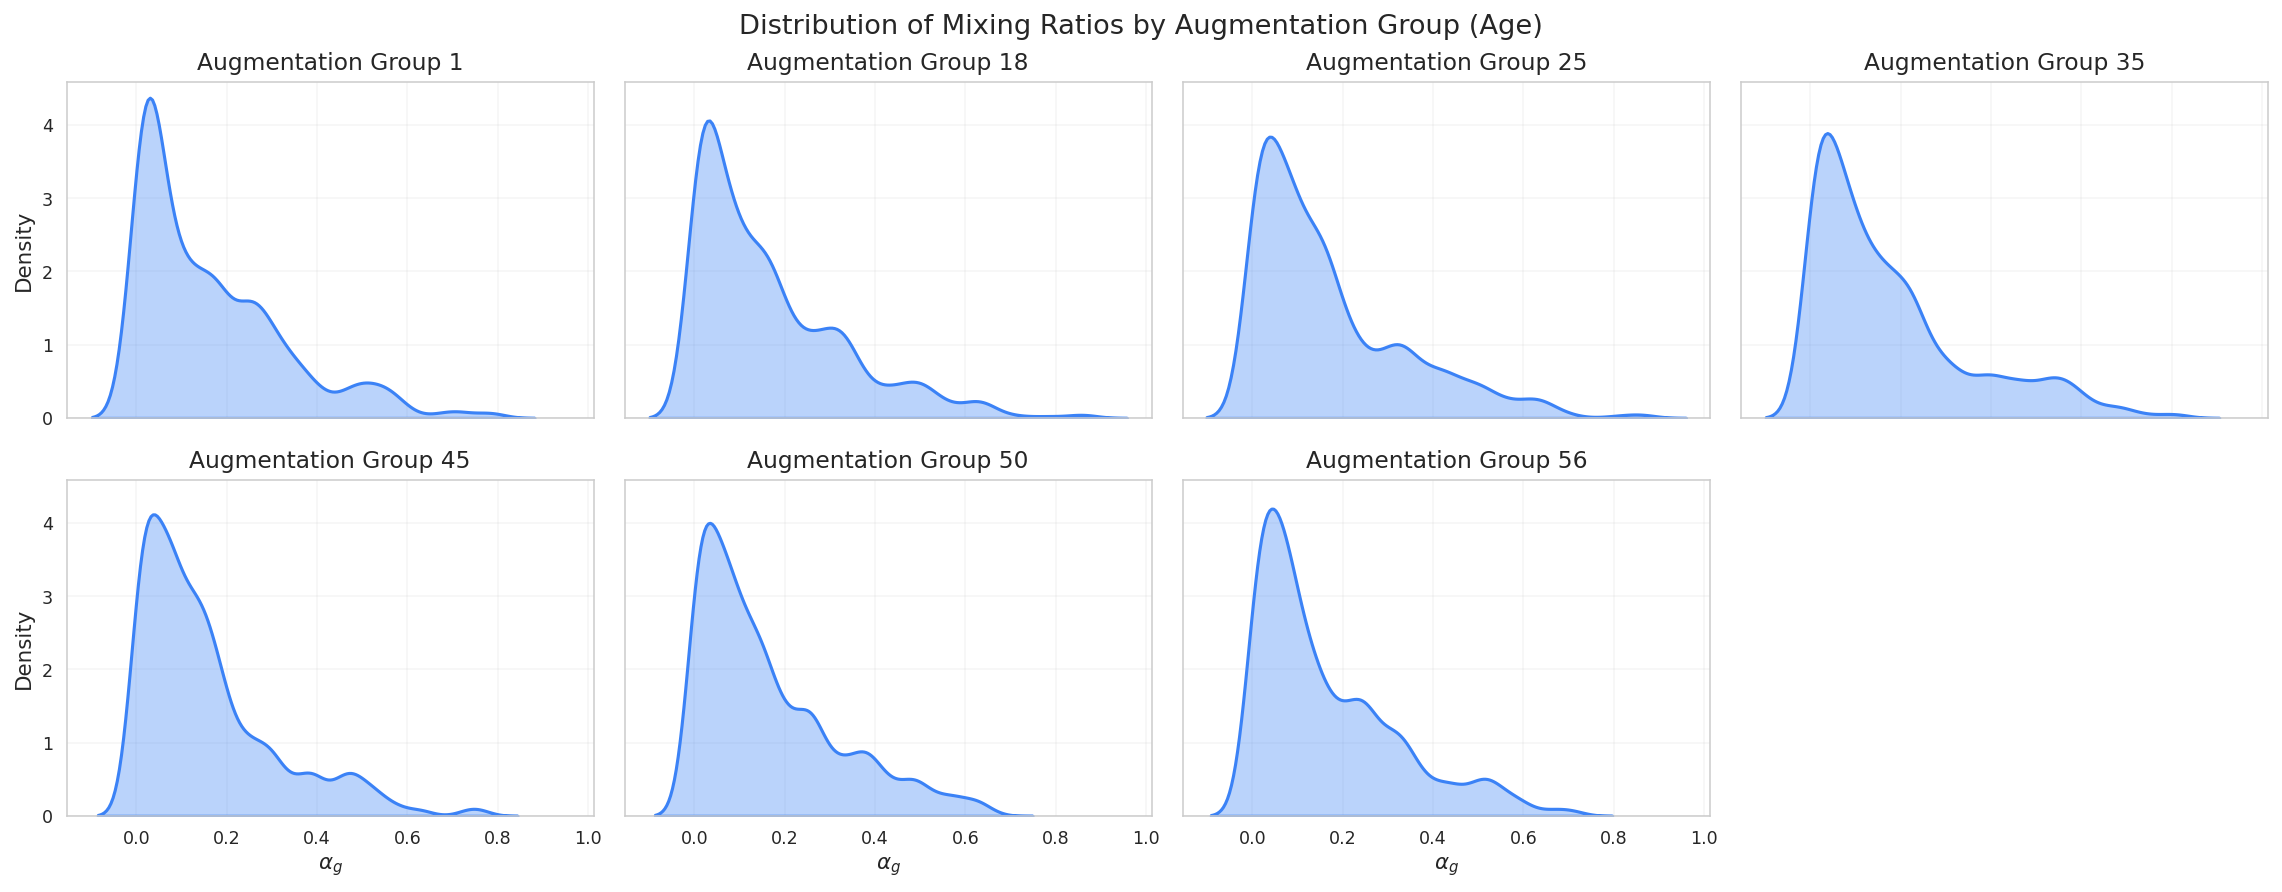

In [4]:
# Figure 1: For each augmentation group, distribution of alpha_g across all trials and all source groups
mix_rows = []
for _, row in df.iterrows():
    for aug_group, w in row["alpha_mix_dict"].items():
        mix_rows.append({
            "augmentation_group": str(aug_group),
            "alpha_g": float(w),
            "source_label": row["source_label"],
            "trial_type": row.get("trial_type", ""),
        })
mix_df = pd.DataFrame(mix_rows)

aug_groups = sorted(mix_df["augmentation_group"].unique().tolist())
n = len(aug_groups)
ncols = min(4, max(1, n))
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.1*ncols, 3.1*nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for i, g in enumerate(aug_groups):
    ax = axes[i]
    vals = mix_df.loc[mix_df["augmentation_group"] == g, "alpha_g"].values
    if len(vals) > 1 and np.std(vals) > 0:
        sns.kdeplot(vals, ax=ax, fill=True, color="#3B82F6", alpha=0.35, linewidth=1.6)
    else:
        ax.hist(vals, bins=10, color="#3B82F6", alpha=0.6)
    ax.set_title(f"Augmentation Group {g}")
    ax.set_xlabel(r"$\alpha_g$")
    ax.set_ylabel("Density")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle(f"Distribution of Mixing Ratios by Augmentation Group ({FEATURE_NAME})", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

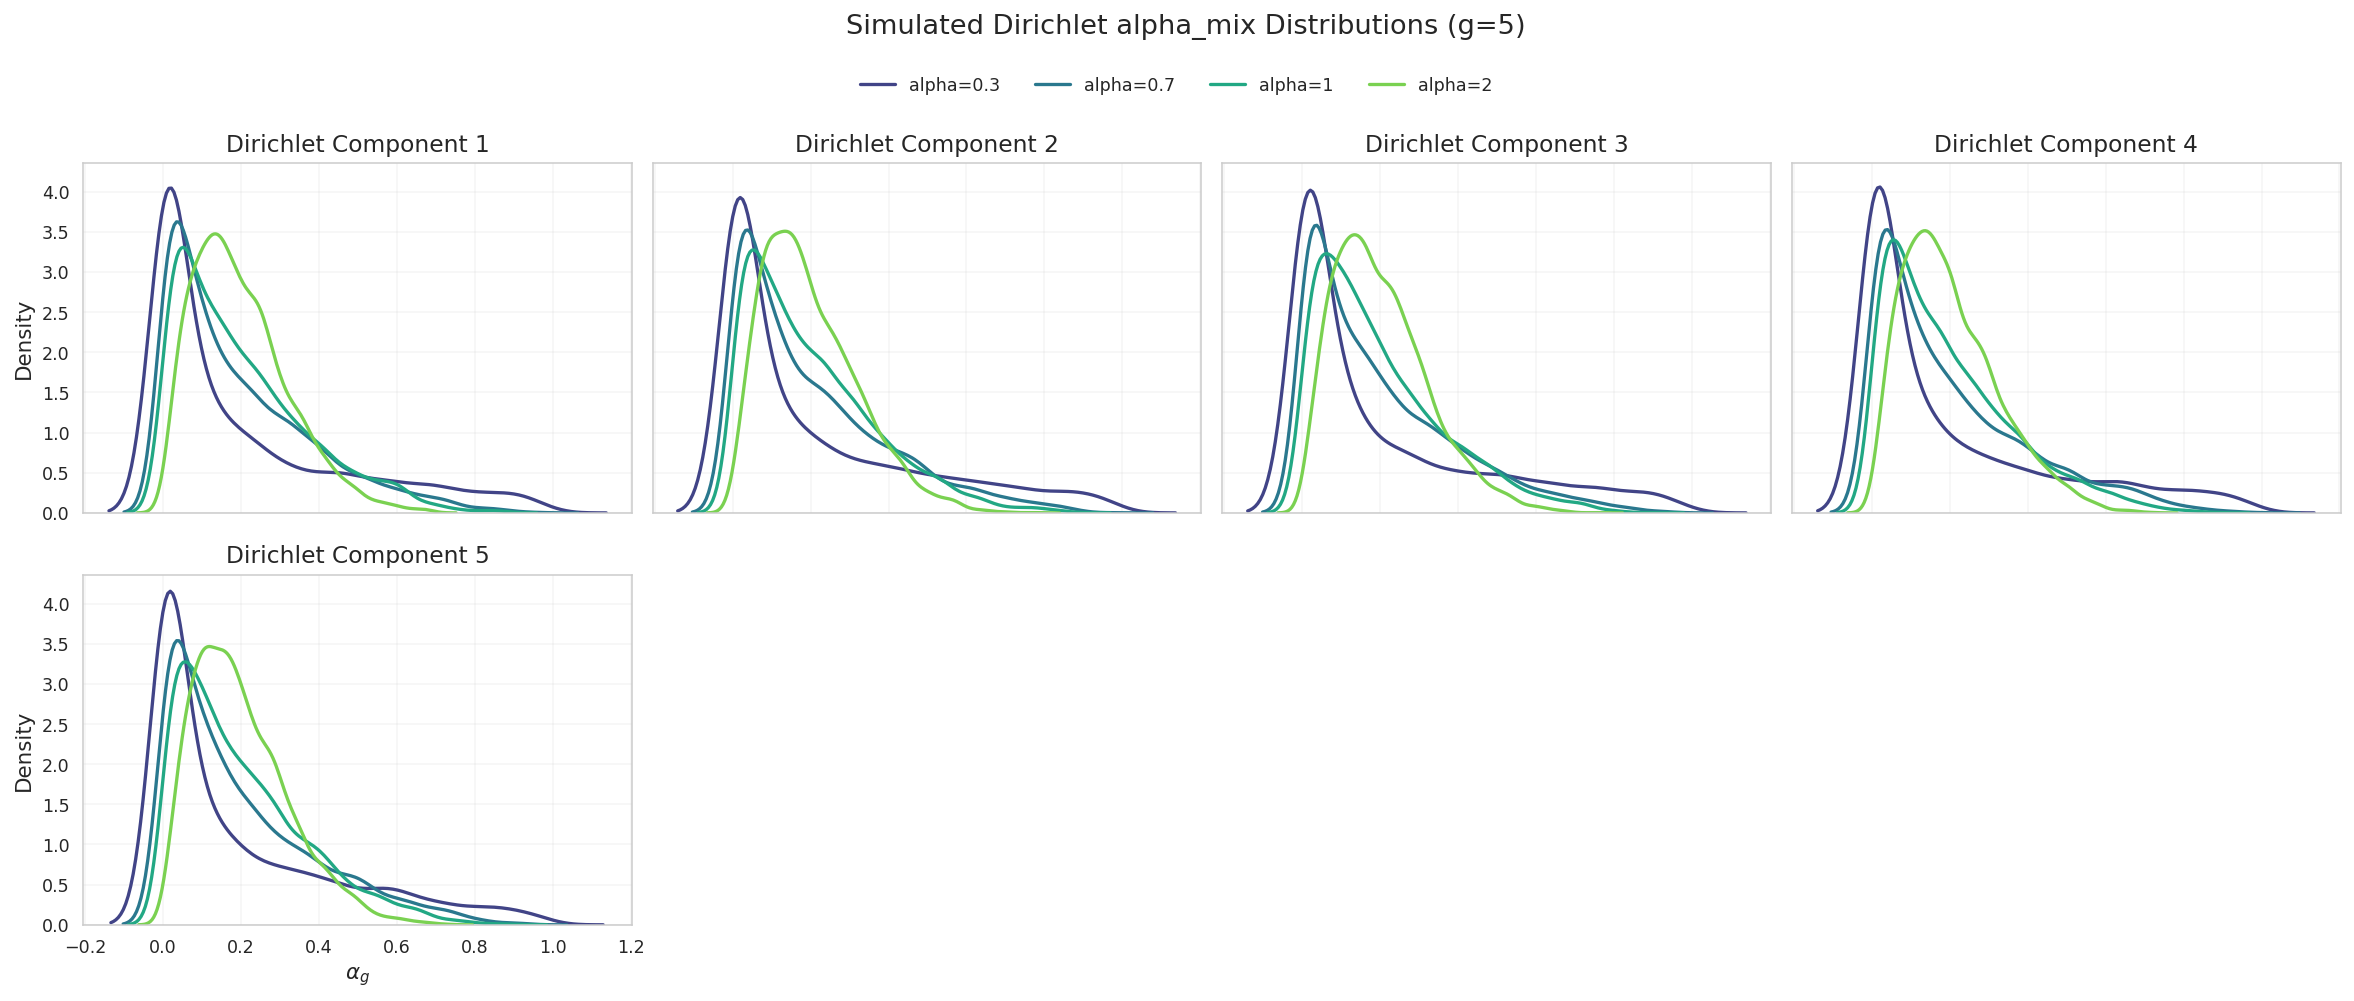

In [5]:
# Simulated alpha_mix distributions from Dirichlet(g, concentration),
# overlaid across multiple concentration values
SIM_G = 5                               # number of augmentation groups/components
SIM_DIRICHLET_ALPHAS = [0.3, 0.7, 1.0, 2.0]
SIM_N = 5000                            # samples per alpha
SIM_SEED = 123

rng = np.random.default_rng(SIM_SEED)
palette = sns.color_palette('viridis', n_colors=len(SIM_DIRICHLET_ALPHAS))

ncols = min(4, SIM_G)
nrows = math.ceil(SIM_G / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2*ncols, 3.2*nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for comp_idx in range(SIM_G):
    ax = axes[comp_idx]
    for j, alpha in enumerate(SIM_DIRICHLET_ALPHAS):
        samples = rng.dirichlet(np.full(SIM_G, alpha), size=SIM_N)[:, comp_idx]
        if len(samples) > 1 and np.std(samples) > 0:
            sns.kdeplot(
                samples,
                ax=ax,
                color=palette[j],
                linewidth=1.7,
                fill=False,
                label=f'alpha={alpha:g}',
            )
        else:
            ax.hist(samples, bins=12, density=True, alpha=0.3, color=palette[j], label=f'alpha={alpha:g}')

    ax.set_title(f'Dirichlet Component {comp_idx+1}')
    ax.set_xlabel(r'$\alpha_g$')
    ax.set_ylabel('Density')

for k in range(SIM_G, len(axes)):
    axes[k].axis('off')

# Single figure-wide legend
handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, ncol=len(SIM_DIRICHLET_ALPHAS), loc='upper center', bbox_to_anchor=(0.5, 1.05), frameon=False)

fig.suptitle(
    f'Simulated Dirichlet alpha_mix Distributions (g={SIM_G})',
    y=1.11,
    fontsize=14,
)
fig.tight_layout()
plt.show()


Source=1, scale=0.2, accepted=5000, attempts=6207, acceptance_rate=0.806


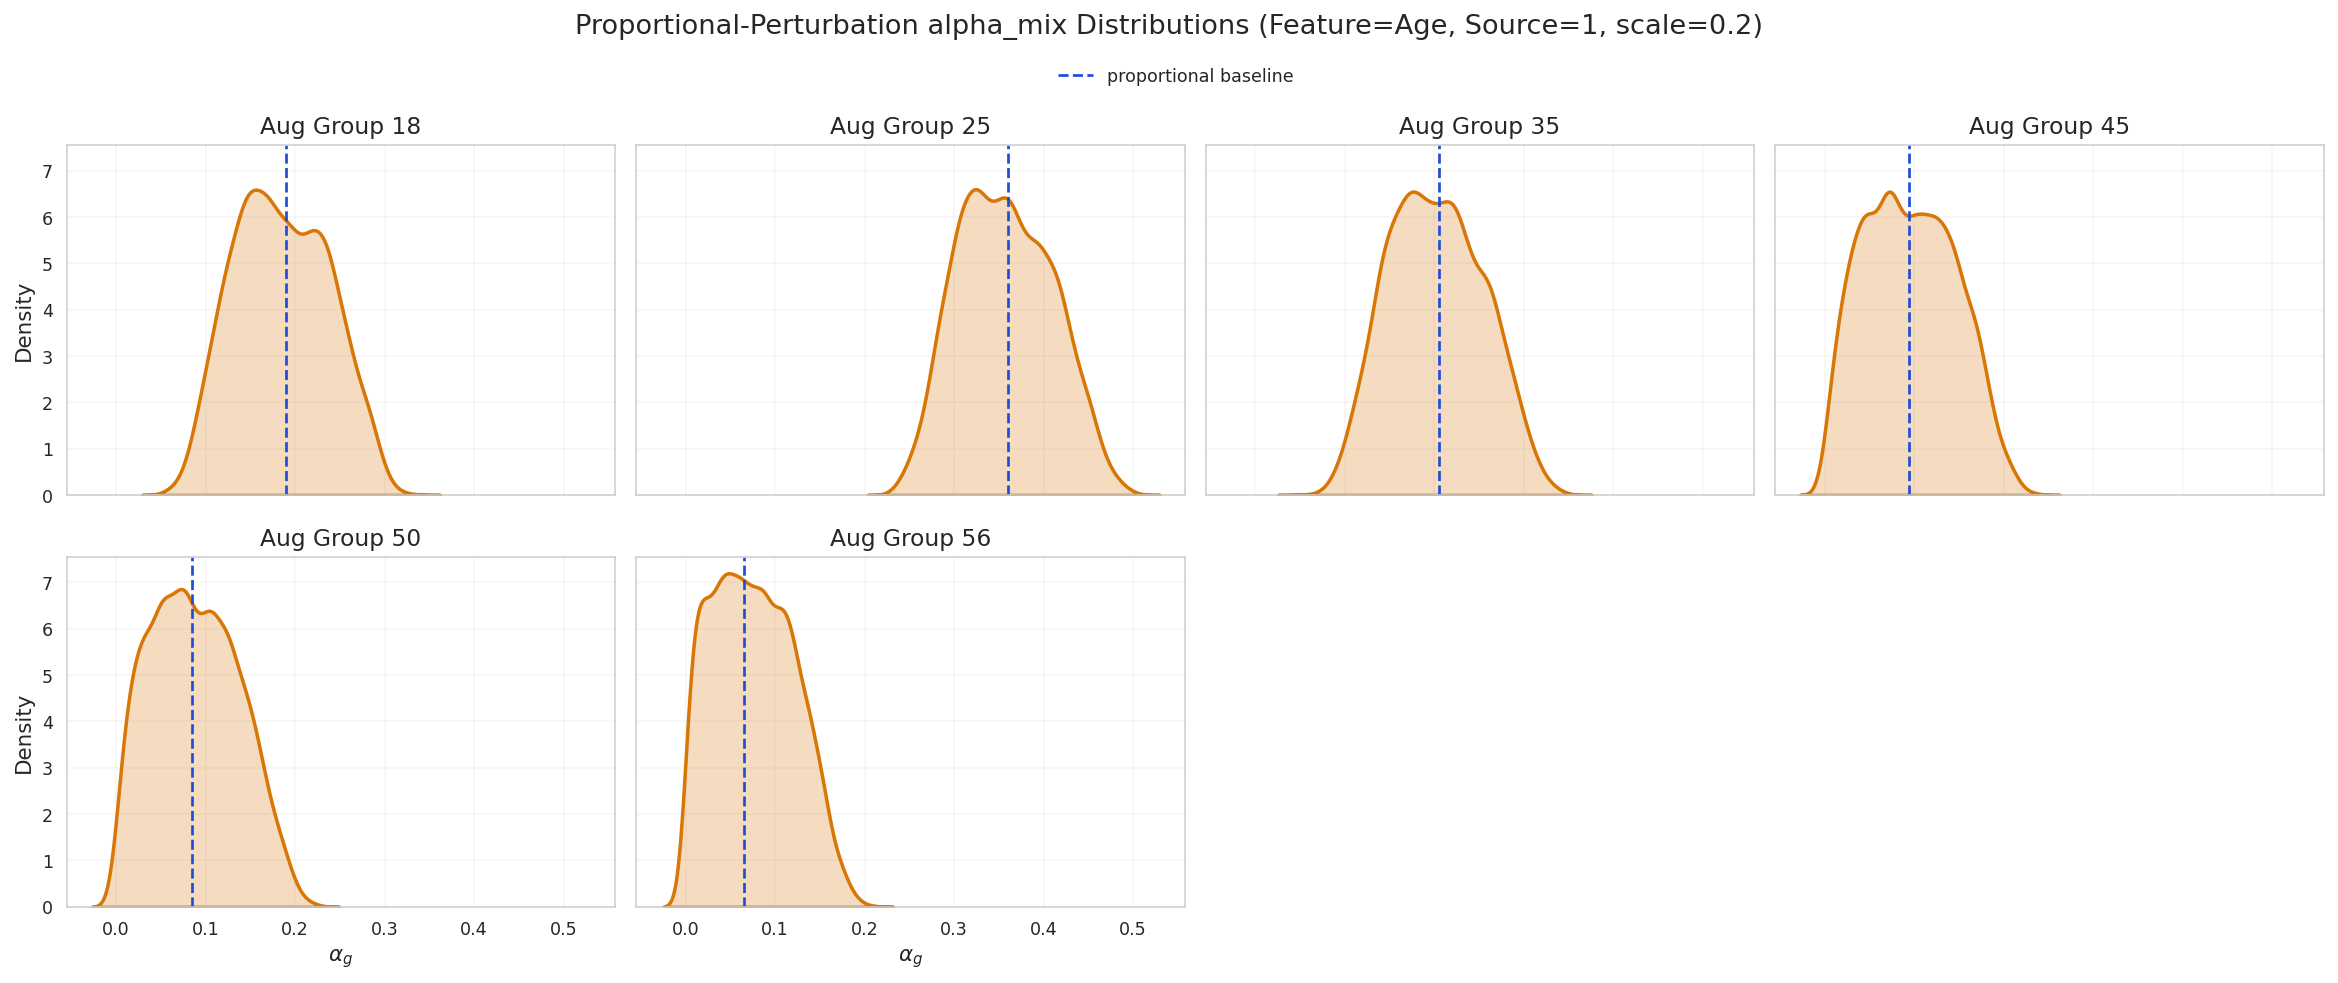

In [6]:
# Simulated alpha_mix distributions under proportional_perturbation for one source group
PP_SOURCE_LABEL = sorted(df_alpha_cv['source_label'].astype(str).unique().tolist())[0]  # choose source group
PP_SCALE = 0.2                 # perturbation scale
PP_N = 5000                    # number of accepted samples
PP_SEED = 123
PP_MAX_ATTEMPTS = 200000

# Get proportional baseline mix x for this source group
prop_rows = df_alpha_cv[
    (df_alpha_cv['source_label'].astype(str) == str(PP_SOURCE_LABEL))
    & (df_alpha_cv['trial_type'].astype(str) == 'proportional')
]
if prop_rows.empty:
    raise ValueError(f"No proportional baseline row found for source_label={PP_SOURCE_LABEL}.")
if len(prop_rows) > 1:
    # If repeated, use the first (they should be identical after CV averaging)
    prop_row = prop_rows.iloc[0]
else:
    prop_row = prop_rows.iloc[0]

x_dict = _parse_alpha_mix(prop_row['alpha_mix_json'])
aug_groups = sorted(x_dict.keys(), key=lambda z: str(z))
x = np.array([float(x_dict[g]) for g in aug_groups], dtype=float)

def sample_proportional_perturbation(base_x, scale, n_samples, seed=0, max_attempts=100000):
    rng = np.random.default_rng(seed)
    accepted = []
    attempts = 0
    d = len(base_x)

    while len(accepted) < n_samples and attempts < max_attempts:
        delta = rng.uniform(0.0, 1.0, size=d)
        delta_p = (delta - delta.mean()) * float(scale)
        mix = base_x + delta_p
        attempts += 1
        if np.all(mix >= 0.0):
            # Sum should already be ~1 because centered perturbation preserves sum,
            # but normalize for numerical stability.
            mix = mix / mix.sum()
            accepted.append(mix)

    if len(accepted) < n_samples:
        raise RuntimeError(
            f"Only accepted {len(accepted)} / {n_samples} samples after {attempts} attempts. "
            "Try a smaller PP_SCALE."
        )

    return np.vstack(accepted), attempts

samples, attempts = sample_proportional_perturbation(
    x, PP_SCALE, PP_N, seed=PP_SEED, max_attempts=PP_MAX_ATTEMPTS
)
print(
    f"Source={PP_SOURCE_LABEL}, scale={PP_SCALE}, accepted={len(samples)}, "
    f"attempts={attempts}, acceptance_rate={len(samples)/attempts:.3f}"
)

n_comp = len(aug_groups)
ncols = min(4, n_comp)
nrows = math.ceil(n_comp / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2*ncols, 3.2*nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for j, g in enumerate(aug_groups):
    ax = axes[j]
    vals = samples[:, j]
    base = x[j]

    if len(vals) > 1 and np.std(vals) > 0:
        sns.kdeplot(vals, ax=ax, color='#D97706', linewidth=1.8, fill=True, alpha=0.25)
    else:
        ax.hist(vals, bins=12, density=True, color='#D97706', alpha=0.5)

    ax.axvline(base, color='#1D4ED8', linestyle='--', linewidth=1.4, label='proportional baseline')
    ax.set_title(f'Aug Group {g}')
    ax.set_xlabel(r'$\alpha_g$')
    ax.set_ylabel('Density')

for k in range(n_comp, len(axes)):
    axes[k].axis('off')

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=1, bbox_to_anchor=(0.5, 1.04), frameon=False)

fig.suptitle(
    f'Proportional-Perturbation alpha_mix Distributions '
    f'(Feature={FEATURE_NAME}, Source={PP_SOURCE_LABEL}, scale={PP_SCALE})',
    y=1.09,
    fontsize=14,
)
fig.tight_layout()
plt.show()


alpha' check: min=0.290, max=1.710, mean row-sum=6.000


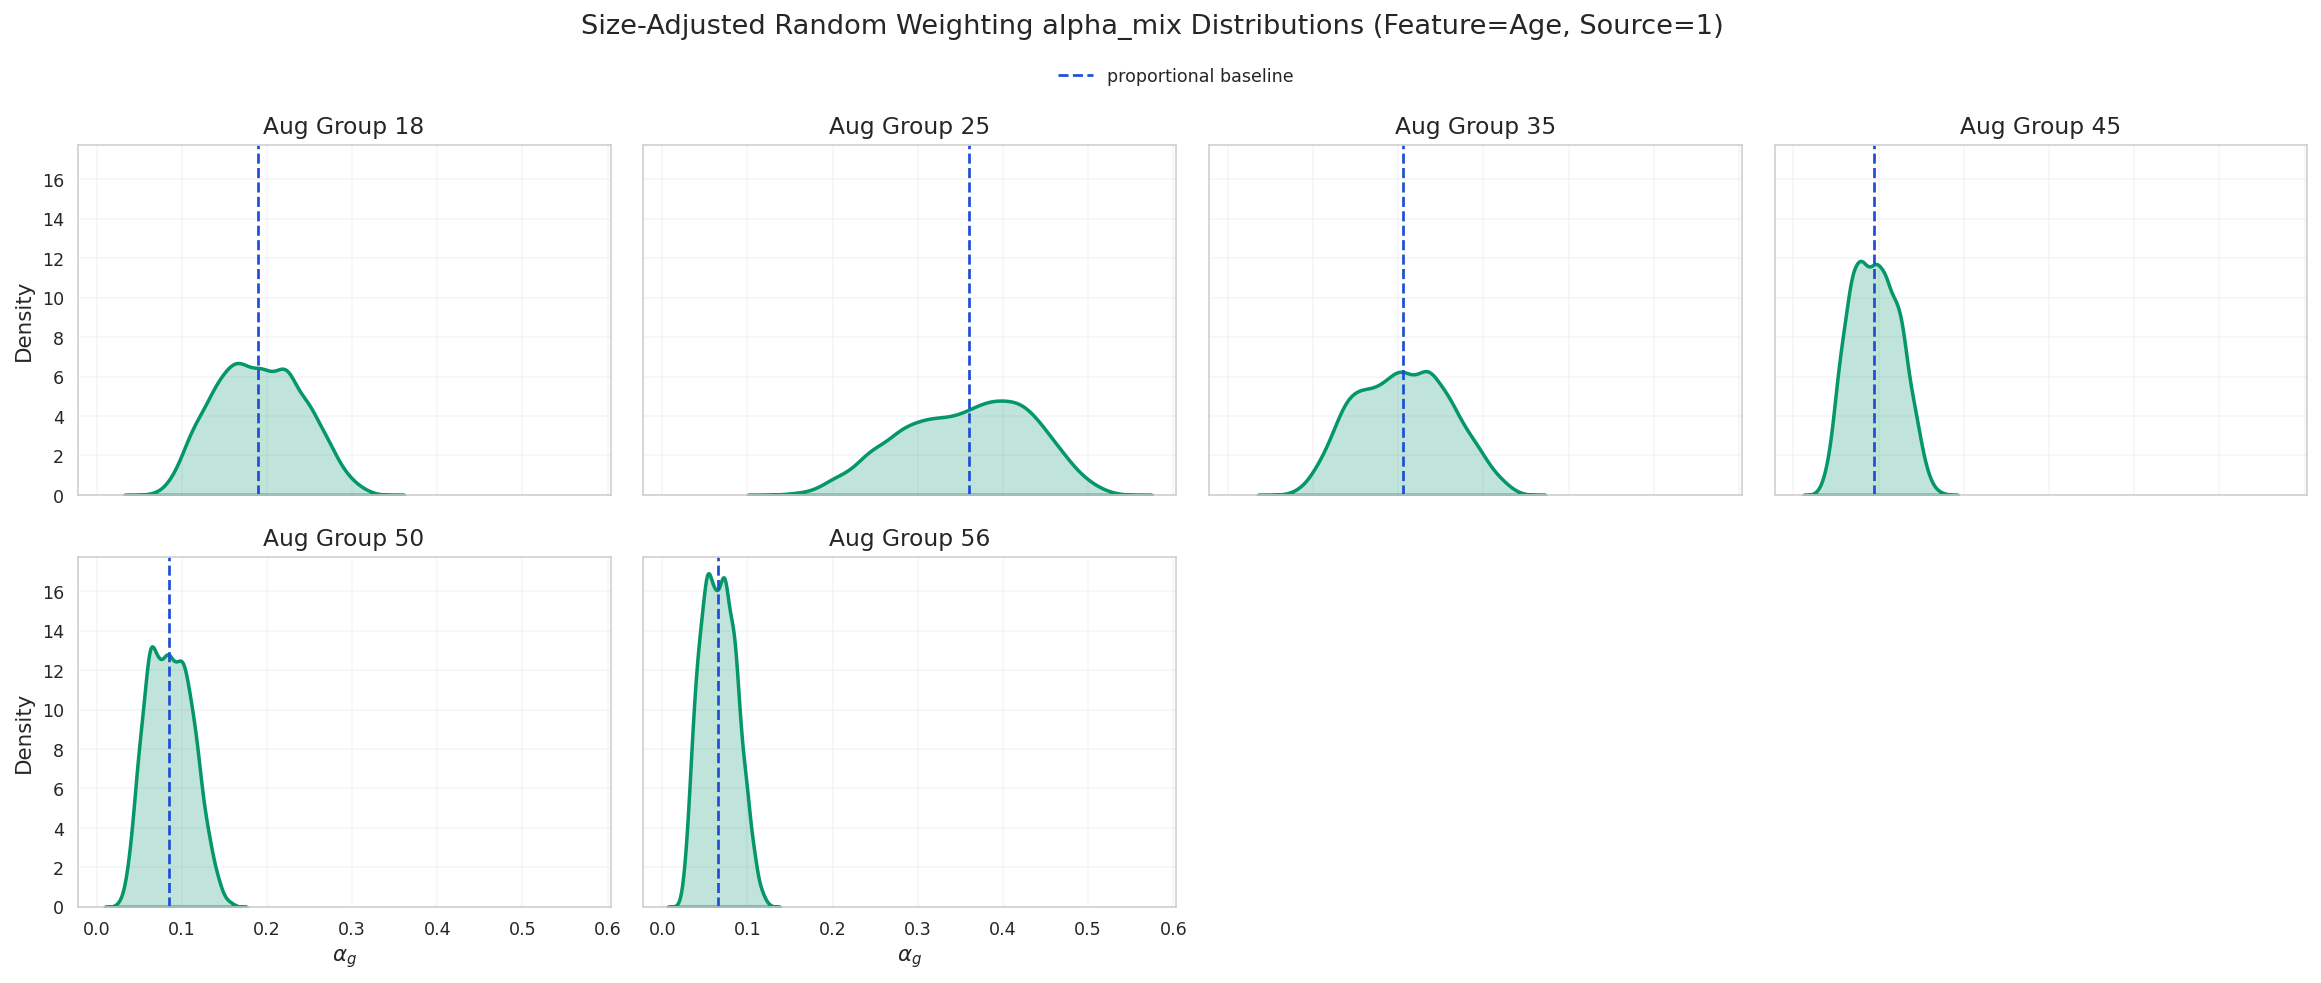

In [7]:
# Simulated alpha_mix distributions for size-adjusted random weighting
# alpha' sampled as: x ~ Uniform([0,1]^d), center x, then alpha' = x + 1
# alpha_mix_g = n_g * alpha'_g / (s · alpha'), where s is group-size vector
WG_SOURCE_LABEL = PP_SOURCE_LABEL if 'PP_SOURCE_LABEL' in globals() else sorted(df_alpha_cv['source_label'].astype(str).unique().tolist())[0]
WG_N = 5000
WG_SEED = 321

# Use proportional baseline to recover relative group-size weights s (scale cancels in the formula)
prop_rows_wg = df_alpha_cv[
    (df_alpha_cv['source_label'].astype(str) == str(WG_SOURCE_LABEL))
    & (df_alpha_cv['trial_type'].astype(str) == 'proportional')
]
if prop_rows_wg.empty:
    raise ValueError(f"No proportional baseline row found for source_label={WG_SOURCE_LABEL}.")

prop_dict_wg = _parse_alpha_mix(prop_rows_wg.iloc[0]['alpha_mix_json'])
wg_groups = sorted(prop_dict_wg.keys(), key=lambda z: str(z))

# Relative group sizes: proportional baseline is n_g / n_aug, so it's proportional to n_g.
s = np.array([float(prop_dict_wg[g]) for g in wg_groups], dtype=float)
if np.any(s <= 0):
    raise ValueError('All augmentation-group sizes must be positive for this simulation.')

rng = np.random.default_rng(WG_SEED)
d = len(wg_groups)

# Sample alpha' via centered Uniform then +1 shift
x = rng.uniform(0.0, 1.0, size=(WG_N, d))
x_centered = x - x.mean(axis=1, keepdims=True)
alpha_prime = x_centered + 1.0

# alpha' sanity checks (with this construction: each component lies in [0.5, 1.5])
assert np.all(alpha_prime >= 0.0), "alpha' contains negative values."
assert np.all(alpha_prime <= 2.0), "alpha' contains values > 2."

# Apply size-adjusted transform
# denominator is dot(s, alpha') per sample
denom = alpha_prime @ s  # shape (WG_N,)
alpha_mix_wg = (alpha_prime * s[None, :]) / denom[:, None]

# Sanity checks for alpha_mix
assert np.all(alpha_mix_wg >= 0), 'alpha_mix contains negative values.'
assert np.allclose(alpha_mix_wg.sum(axis=1), 1.0, atol=1e-8), 'alpha_mix rows must sum to 1.'

print(
    f"alpha' check: min={alpha_prime.min():.3f}, max={alpha_prime.max():.3f}, "
    f"mean row-sum={alpha_prime.sum(axis=1).mean():.3f}"
)

n_comp = len(wg_groups)
ncols = min(4, n_comp)
nrows = math.ceil(n_comp / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2*ncols, 3.2*nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for j, g in enumerate(wg_groups):
    ax = axes[j]
    vals = alpha_mix_wg[:, j]
    base = s[j] / s.sum()  # proportional baseline for this component

    if len(vals) > 1 and np.std(vals) > 0:
        sns.kdeplot(vals, ax=ax, color='#059669', linewidth=1.8, fill=True, alpha=0.25)
    else:
        ax.hist(vals, bins=12, density=True, color='#059669', alpha=0.5)

    ax.axvline(base, color='#1D4ED8', linestyle='--', linewidth=1.4, label='proportional baseline')
    ax.set_title(f'Aug Group {g}')
    ax.set_xlabel(r'$\alpha_g$')
    ax.set_ylabel('Density')

for k in range(n_comp, len(axes)):
    axes[k].axis('off')

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=1, bbox_to_anchor=(0.5, 1.04), frameon=False)

fig.suptitle(
    f"Size-Adjusted Random Weighting alpha_mix Distributions (Feature={FEATURE_NAME}, Source={WG_SOURCE_LABEL})",
    y=1.09,
    fontsize=14,
)
fig.tight_layout()
plt.show()


Overlay source=1 | components=6 | observed=220 | proportional_perturbation=5000 | size_adjusted=5000


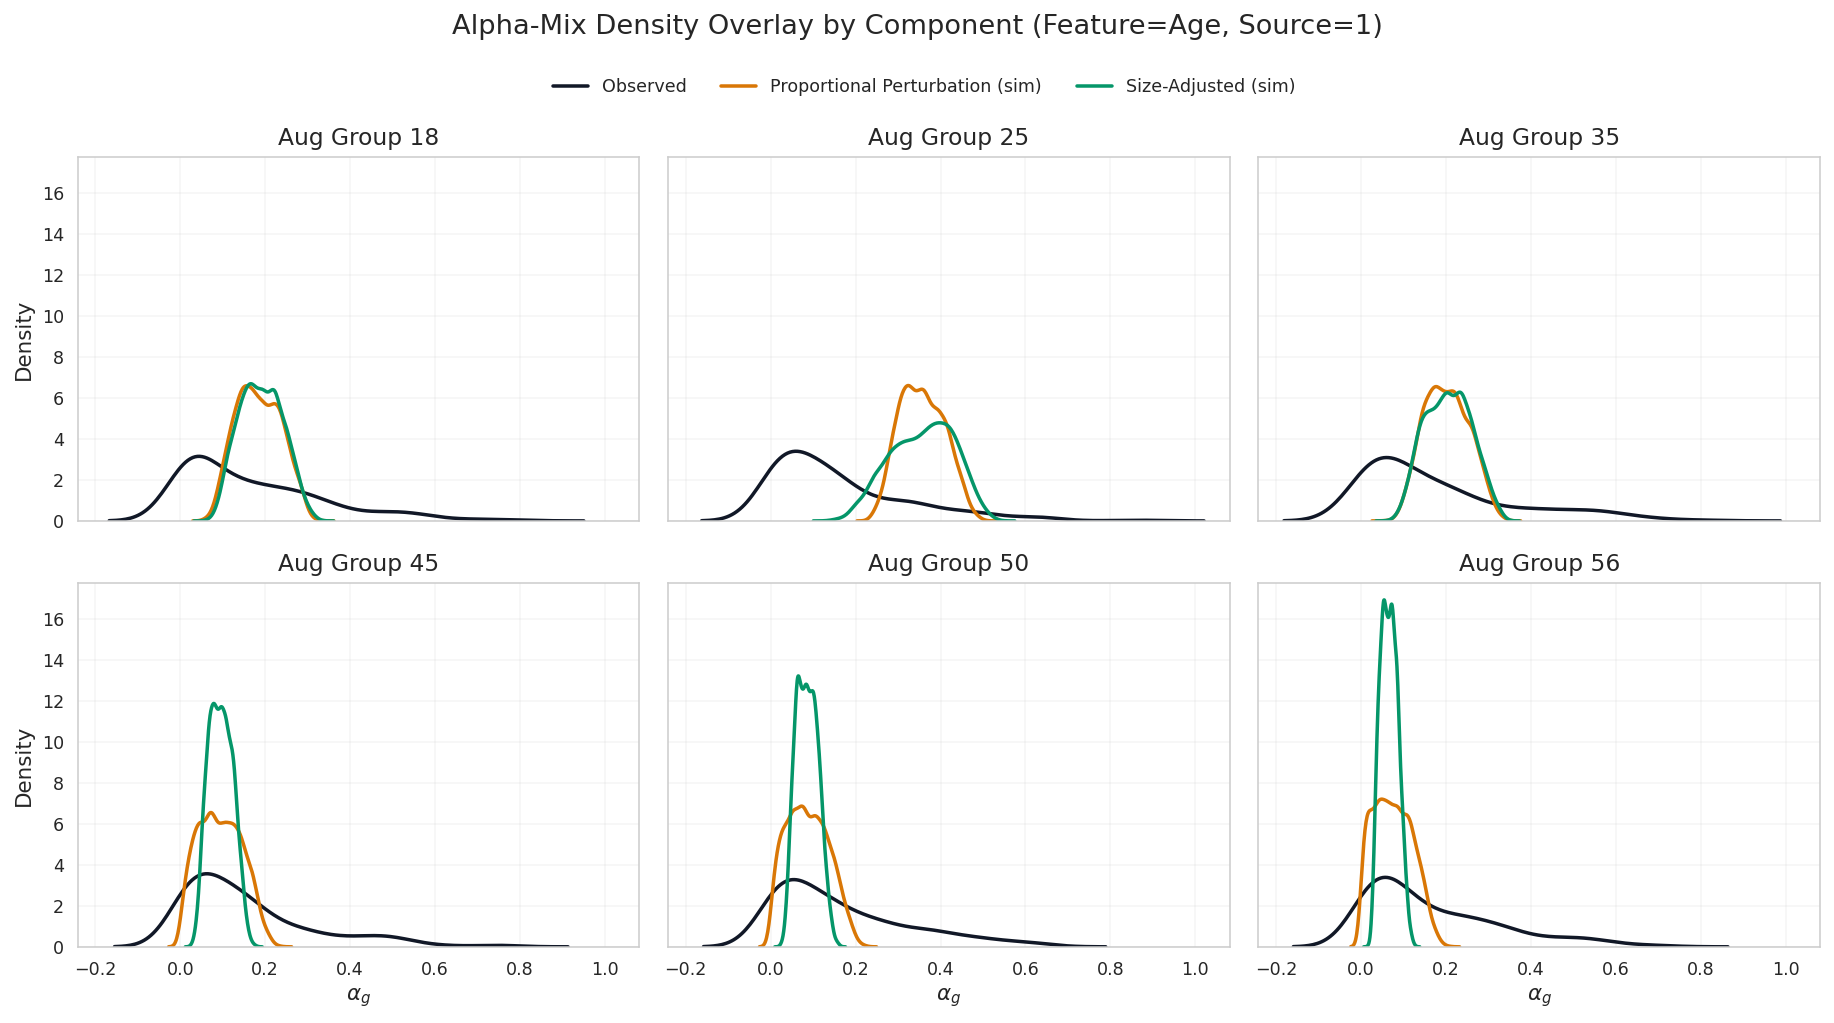

In [18]:
# Overlay alpha_mix densities: observed vs simulated proportional_perturbation vs simulated size-adjusted
if 'df_alpha_cv' not in globals():
    raise RuntimeError('Run the CV aggregation cell first (df_alpha_cv missing).')
if 'samples' not in globals():
    raise RuntimeError('Run the proportional_perturbation simulation cell first (samples missing).')
if 'alpha_mix_wg' not in globals():
    raise RuntimeError('Run the size-adjusted simulation cell first (alpha_mix_wg missing).')

OVERLAY_SOURCE_LABEL = str(PP_SOURCE_LABEL if 'PP_SOURCE_LABEL' in globals() else WG_SOURCE_LABEL)
BASELINE_TYPES = {'no_augmentation', 'proportional', 'stratified'}
OBS_INCLUDE_BASELINES = False

# Component ordering from simulation cells
comp_labels = list(aug_groups) if 'aug_groups' in globals() else list(wg_groups)

# Build observed alpha_mix matrix for matching source/group order
obs_rows = df_alpha_cv[df_alpha_cv['source_label'].astype(str) == OVERLAY_SOURCE_LABEL].copy()
if not OBS_INCLUDE_BASELINES:
    obs_rows = obs_rows[~obs_rows['trial_type'].astype(str).isin(BASELINE_TYPES)].copy()
if obs_rows.empty:
    raise RuntimeError(f'No observed rows for source={OVERLAY_SOURCE_LABEL}.')

obs_mat = []
for _, r in obs_rows.iterrows():
    mix = r['alpha_mix_dict'] if 'alpha_mix_dict' in r else _parse_alpha_mix(r['alpha_mix_json'])
    obs_mat.append([float(mix.get(g, 0.0)) for g in comp_labels])
obs_mat = np.asarray(obs_mat, dtype=float)

# Simulated matrices should already align to the same component order
pp_mat = np.asarray(samples, dtype=float)
sa_mat = np.asarray(alpha_mix_wg, dtype=float)

if pp_mat.shape[1] != len(comp_labels) or sa_mat.shape[1] != len(comp_labels):
    raise RuntimeError('Component dimension mismatch between observed and simulated matrices.')

print(
    f'Overlay source={OVERLAY_SOURCE_LABEL} | components={len(comp_labels)} | '
    f'observed={len(obs_mat)} | proportional_perturbation={len(pp_mat)} | size_adjusted={len(sa_mat)}'
)

n_comp = len(comp_labels)
ncols = min(3, n_comp)
nrows = math.ceil(n_comp / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.4*ncols, 3.3*nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

palette = {
    'Observed': '#111827',
    'Proportional Perturbation (sim)': '#D97706',
    'Size-Adjusted (sim)': '#059669',
}

for j, g in enumerate(comp_labels):
    ax = axes[j]
    data_map = {
        'Observed': obs_mat[:, j],
        'Proportional Perturbation (sim)': pp_mat[:, j],
        'Size-Adjusted (sim)': sa_mat[:, j],
    }

    for name, vals in data_map.items():
        vals = np.asarray(vals, dtype=float)
        vals = vals[np.isfinite(vals)]
        if len(vals) >= 2 and np.std(vals) > 0:
            sns.kdeplot(vals, ax=ax, fill=False, linewidth=1.8, color=palette[name], label=name)
        elif len(vals) > 0:
            ax.axvline(float(vals[0]), color=palette[name], linewidth=1.8, label=f'{name} (single value)')

    ax.set_title(f'Aug Group {g}')
    ax.set_xlabel(r'$\alpha_g$')
    ax.set_ylabel('Density')

for k in range(n_comp, len(axes)):
    axes[k].axis('off')

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.04), frameon=False)

fig.suptitle(
    f'Alpha-Mix Density Overlay by Component (Feature={FEATURE_NAME}, Source={OVERLAY_SOURCE_LABEL})',
    y=1.10,
    fontsize=14,
)
fig.tight_layout()
plt.show()


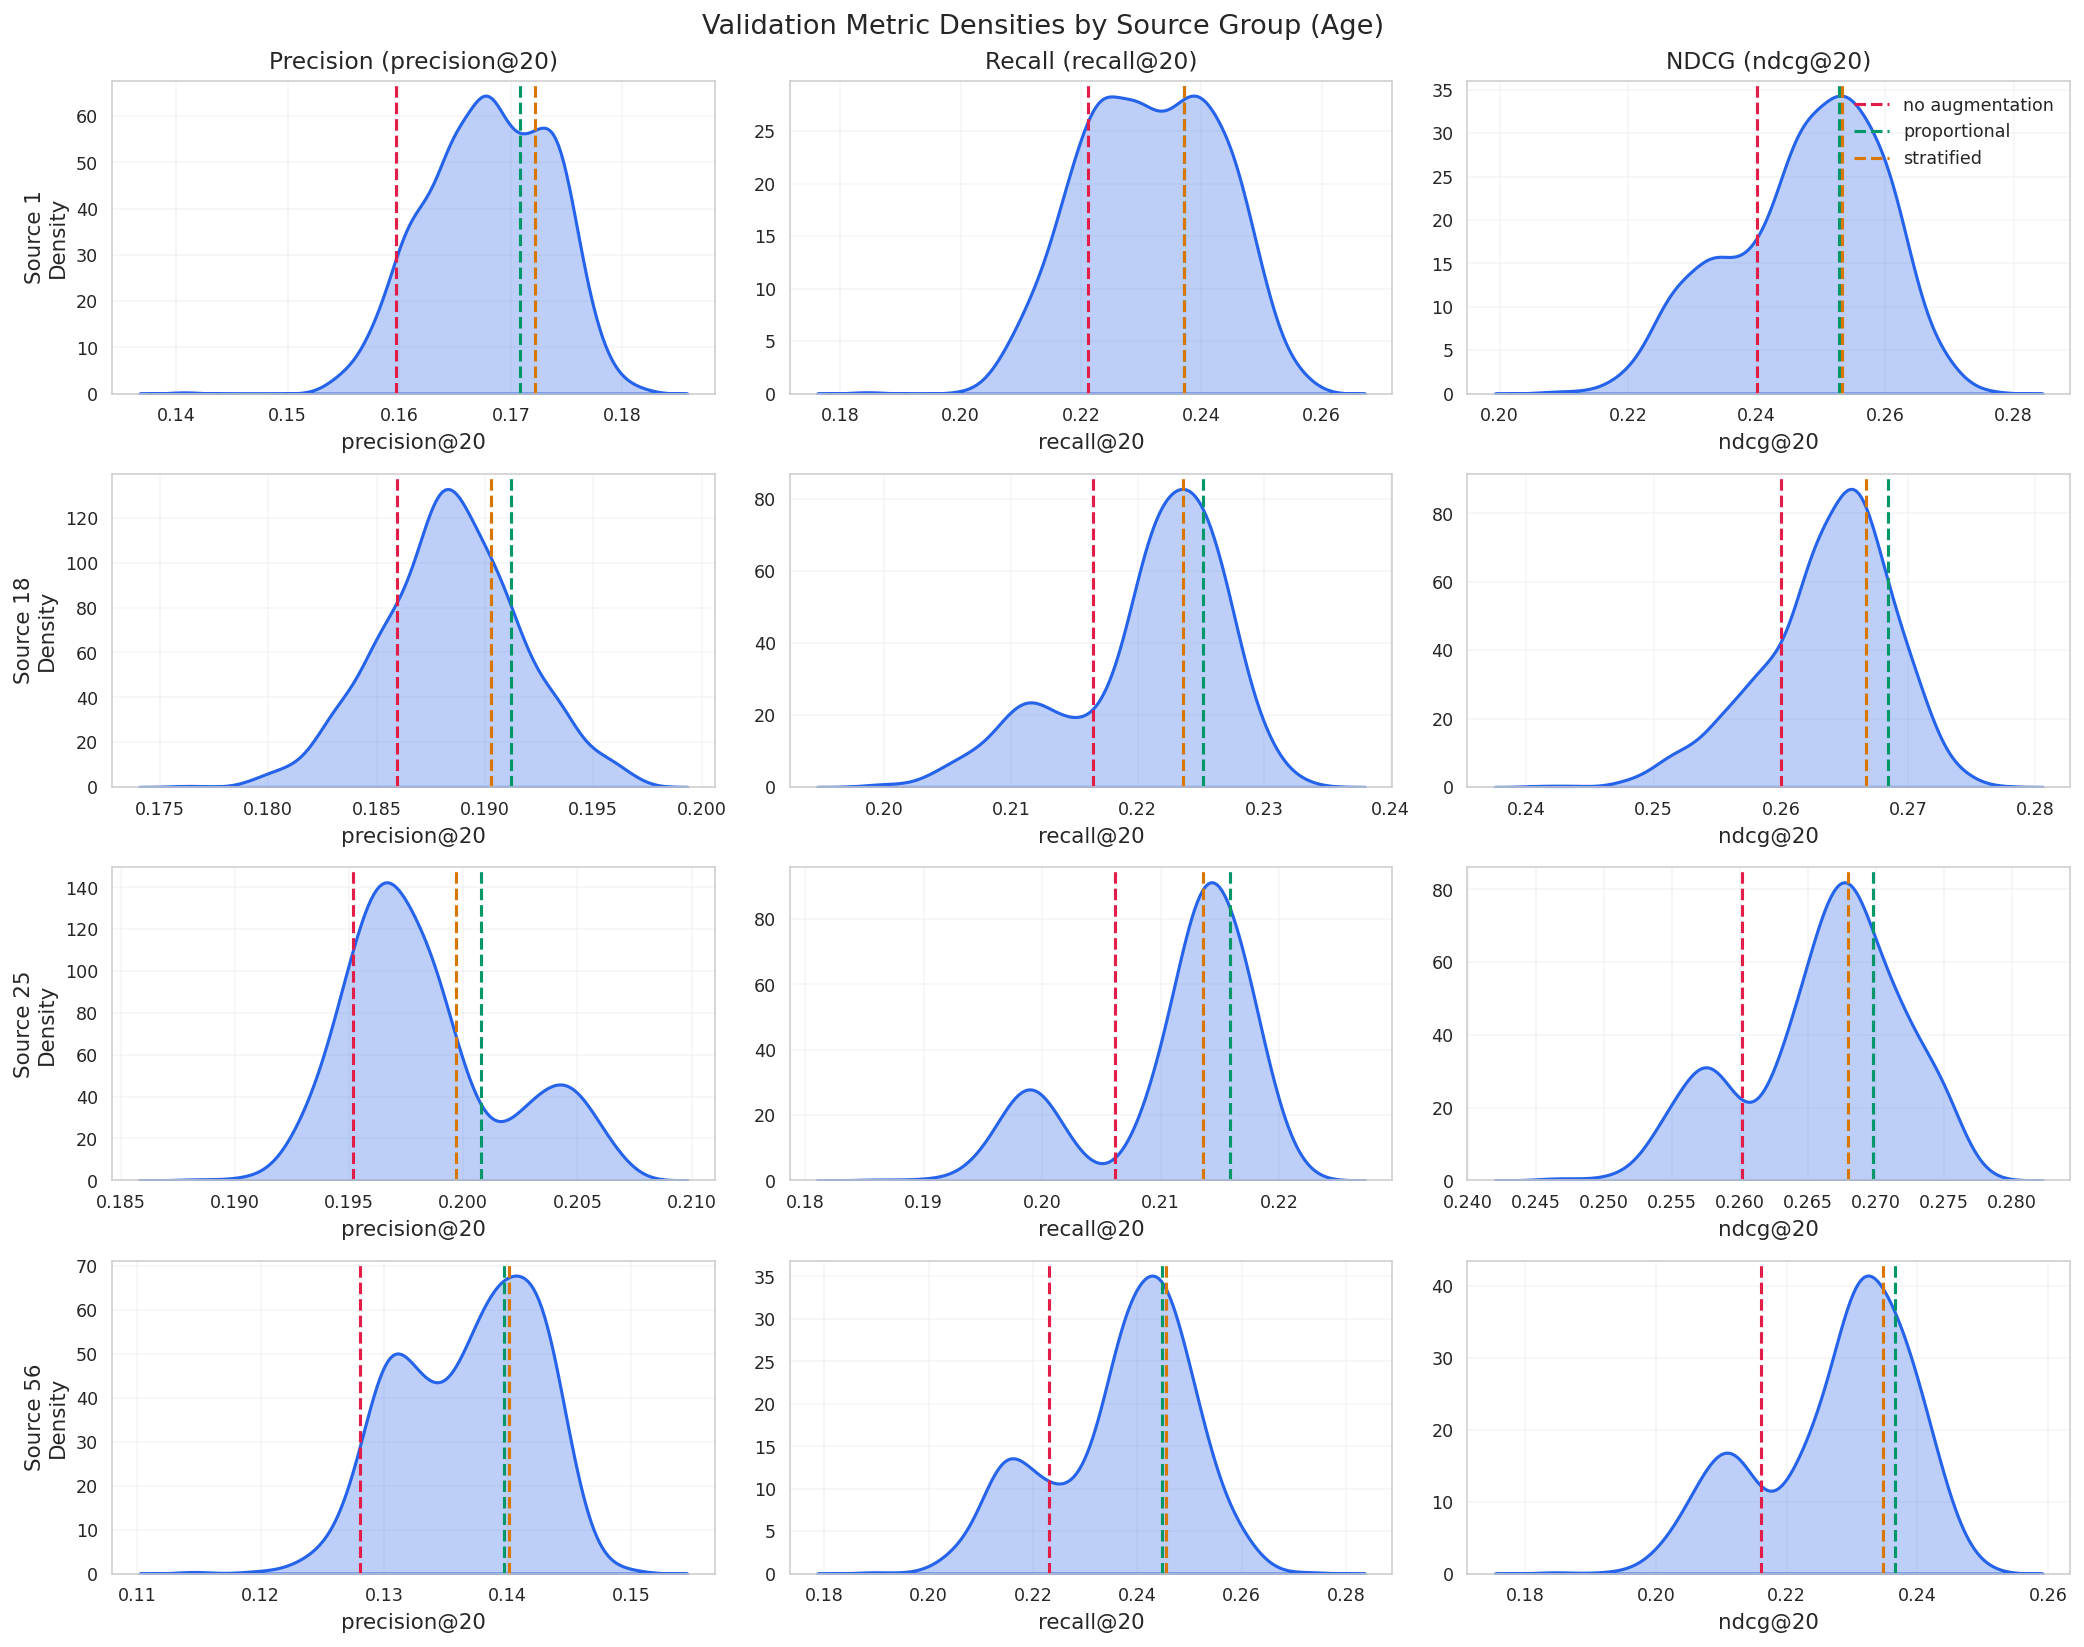

In [9]:
# Figure 2: Ranking metric densities (rows=source groups, cols=metrics),
# with baseline vertical lines: no_augmentation, proportional, stratified
source_groups = sorted(df["source_label"].unique().tolist())
metric_order = ["Precision", "Recall", "NDCG"]

fig, axes = plt.subplots(len(source_groups), len(metric_order), figsize=(5.0*len(metric_order), 2.9*len(source_groups)), sharex=False, sharey=False)
if len(source_groups) == 1:
    axes = np.array([axes])

baseline_colors = {
    "no_augmentation": "#E11D48",
    "proportional": "#059669",
    "stratified": "#D97706",
}

for r, src in enumerate(source_groups):
    sdf = df[df["source_label"] == src].copy()
    for c, mname in enumerate(metric_order):
        ax = axes[r, c]
        col = METRIC_COLS[mname]
        vals = sdf[col].dropna().values

        if len(vals) > 1 and np.std(vals) > 0:
            sns.kdeplot(vals, ax=ax, fill=True, color="#2563EB", alpha=0.30, linewidth=1.6)
        else:
            ax.hist(vals, bins=10, color="#2563EB", alpha=0.6, density=True)

        for btype, color in baseline_colors.items():
            bvals = sdf.loc[sdf["trial_type"] == btype, col].dropna().values
            if len(bvals) > 0:
                ax.axvline(float(np.mean(bvals)), color=color, linestyle="--", linewidth=1.6, label=btype.replace("_", " "))

        if r == 0:
            ax.set_title(f"{mname} ({col})")
        if c == 0:
            ax.set_ylabel(f"Source {src}\nDensity")
        else:
            ax.set_ylabel("")
        ax.set_xlabel(col)

        if r == 0 and c == len(metric_order) - 1:
            handles, labels = ax.get_legend_handles_labels()
            if handles:
                ax.legend(handles, labels, frameon=False, loc="upper right")

fig.suptitle(f"Validation Metric Densities by Source Group ({FEATURE_NAME})", y=1.01, fontsize=14)
fig.tight_layout()
plt.show()

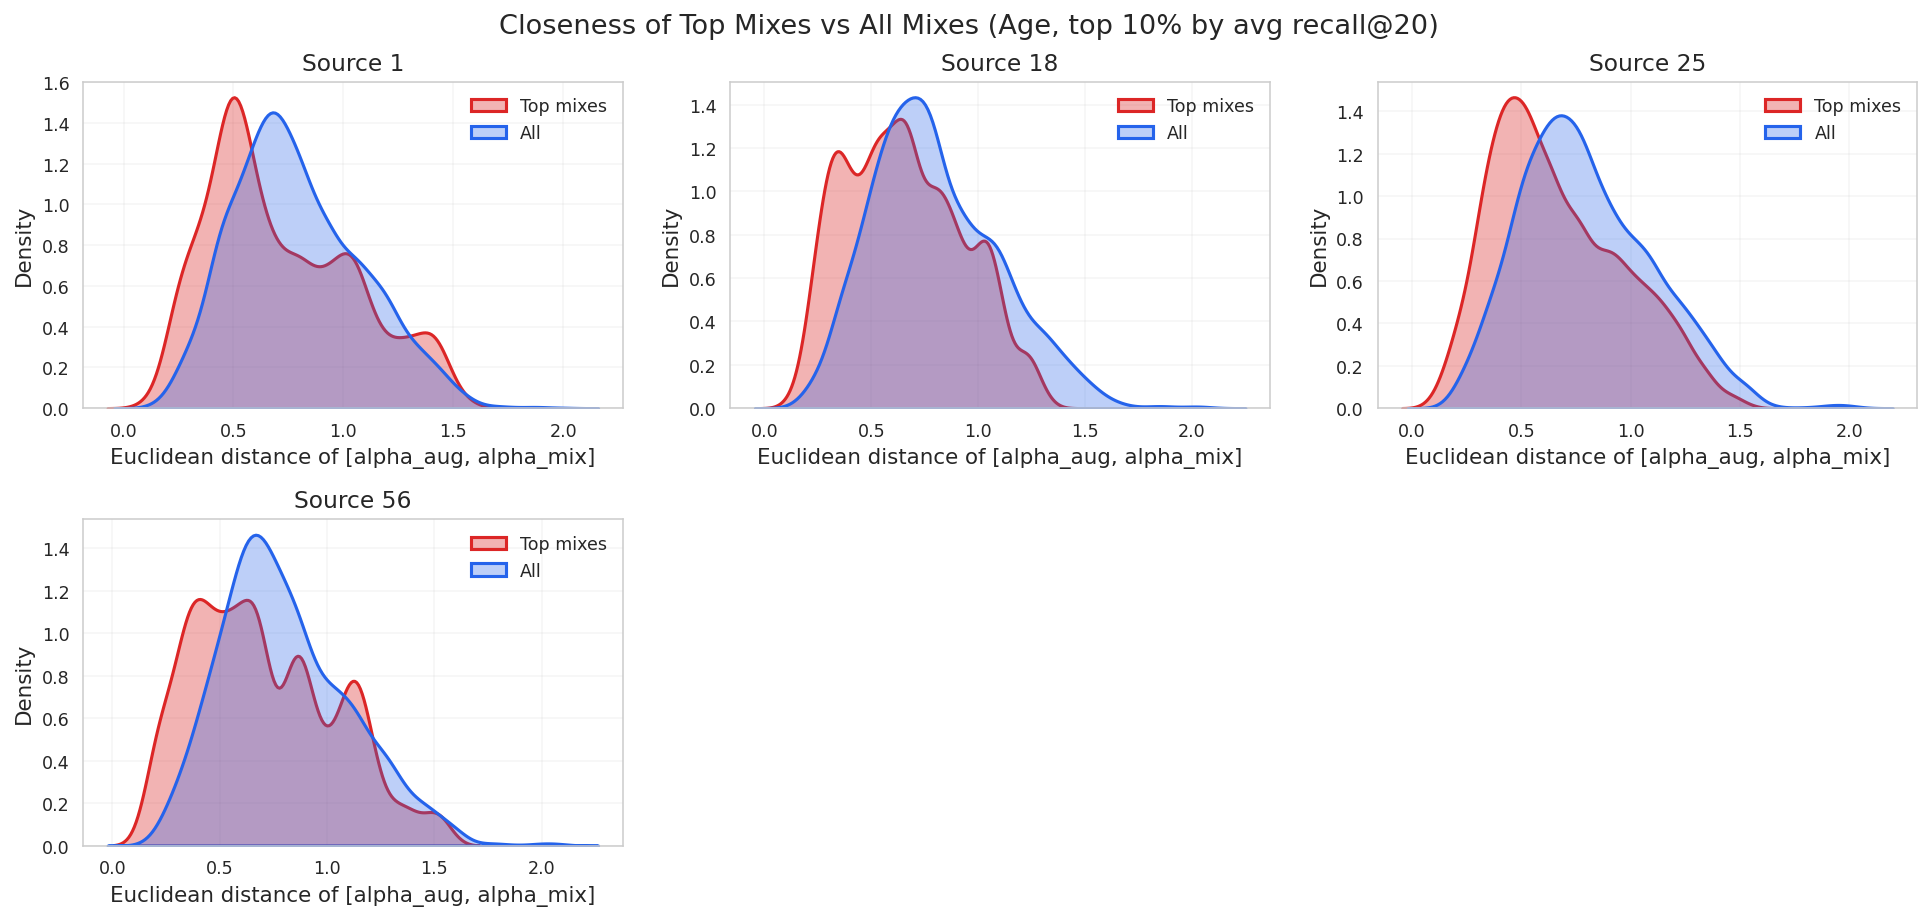

In [10]:
# Figure 3: Closeness of best mixes (top 10% by average CV Recall@k) vs all mixes
recall_col = METRIC_COLS['Recall']
rng = np.random.default_rng(RANDOM_STATE)

def sample_pair_distances(vectors, n_samples, rng):
    if len(vectors) < 2:
        return np.array([])
    idx1 = rng.integers(0, len(vectors), size=n_samples)
    idx2 = rng.integers(0, len(vectors), size=n_samples)
    same = idx1 == idx2
    if np.any(same):
        idx2[same] = (idx2[same] + 1) % len(vectors)
    d = np.linalg.norm(vectors[idx1] - vectors[idx2], axis=1)
    return d

source_groups = sorted(df_alpha_cv['source_label'].unique().tolist())
ncols = min(3, max(1, len(source_groups)))
nrows = math.ceil(len(source_groups) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.7*ncols, 3.2*nrows), sharex=False, sharey=False)
axes = np.array(axes).reshape(-1)

for i, src in enumerate(source_groups):
    ax = axes[i]
    sdf = df_alpha_cv[df_alpha_cv['source_label'] == src].copy()

    aug_labels = sorted({k for dct in sdf['alpha_mix_dict'] for k in dct.keys()})
    def to_vec(row):
        mix_vals = [float(row['alpha_mix_dict'].get(lbl, 0.0)) for lbl in aug_labels]
        return np.array([float(row['alpha_aug'])] + mix_vals, dtype=float)

    vecs = np.vstack(sdf.apply(to_vec, axis=1).values)
    thresh = np.quantile(sdf[recall_col].values, 0.9)
    top_mask = sdf[recall_col].values >= thresh
    vecs_top = vecs[top_mask]

    d_all = sample_pair_distances(vecs, PAIR_SAMPLES, rng)
    d_top = sample_pair_distances(vecs_top, PAIR_SAMPLES, rng)

    if len(d_top) > 1 and np.std(d_top) > 0:
        sns.kdeplot(d_top, ax=ax, fill=True, alpha=0.35, linewidth=1.6, color='#DC2626', label='Top mixes')
    elif len(d_top) > 0:
        ax.hist(d_top, bins=10, density=True, alpha=0.5, color='#DC2626', label='Top mixes')

    if len(d_all) > 1 and np.std(d_all) > 0:
        sns.kdeplot(d_all, ax=ax, fill=True, alpha=0.30, linewidth=1.6, color='#2563EB', label='All')
    elif len(d_all) > 0:
        ax.hist(d_all, bins=10, density=True, alpha=0.4, color='#2563EB', label='All')

    ax.set_title(f'Source {src}')
    ax.set_xlabel('Euclidean distance of [alpha_aug, alpha_mix]')
    ax.set_ylabel('Density')
    ax.legend(frameon=False)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle(f'Closeness of Top Mixes vs All Mixes ({FEATURE_NAME}, top 10% by avg {recall_col})', y=1.02, fontsize=14)
fig.tight_layout()
plt.show()


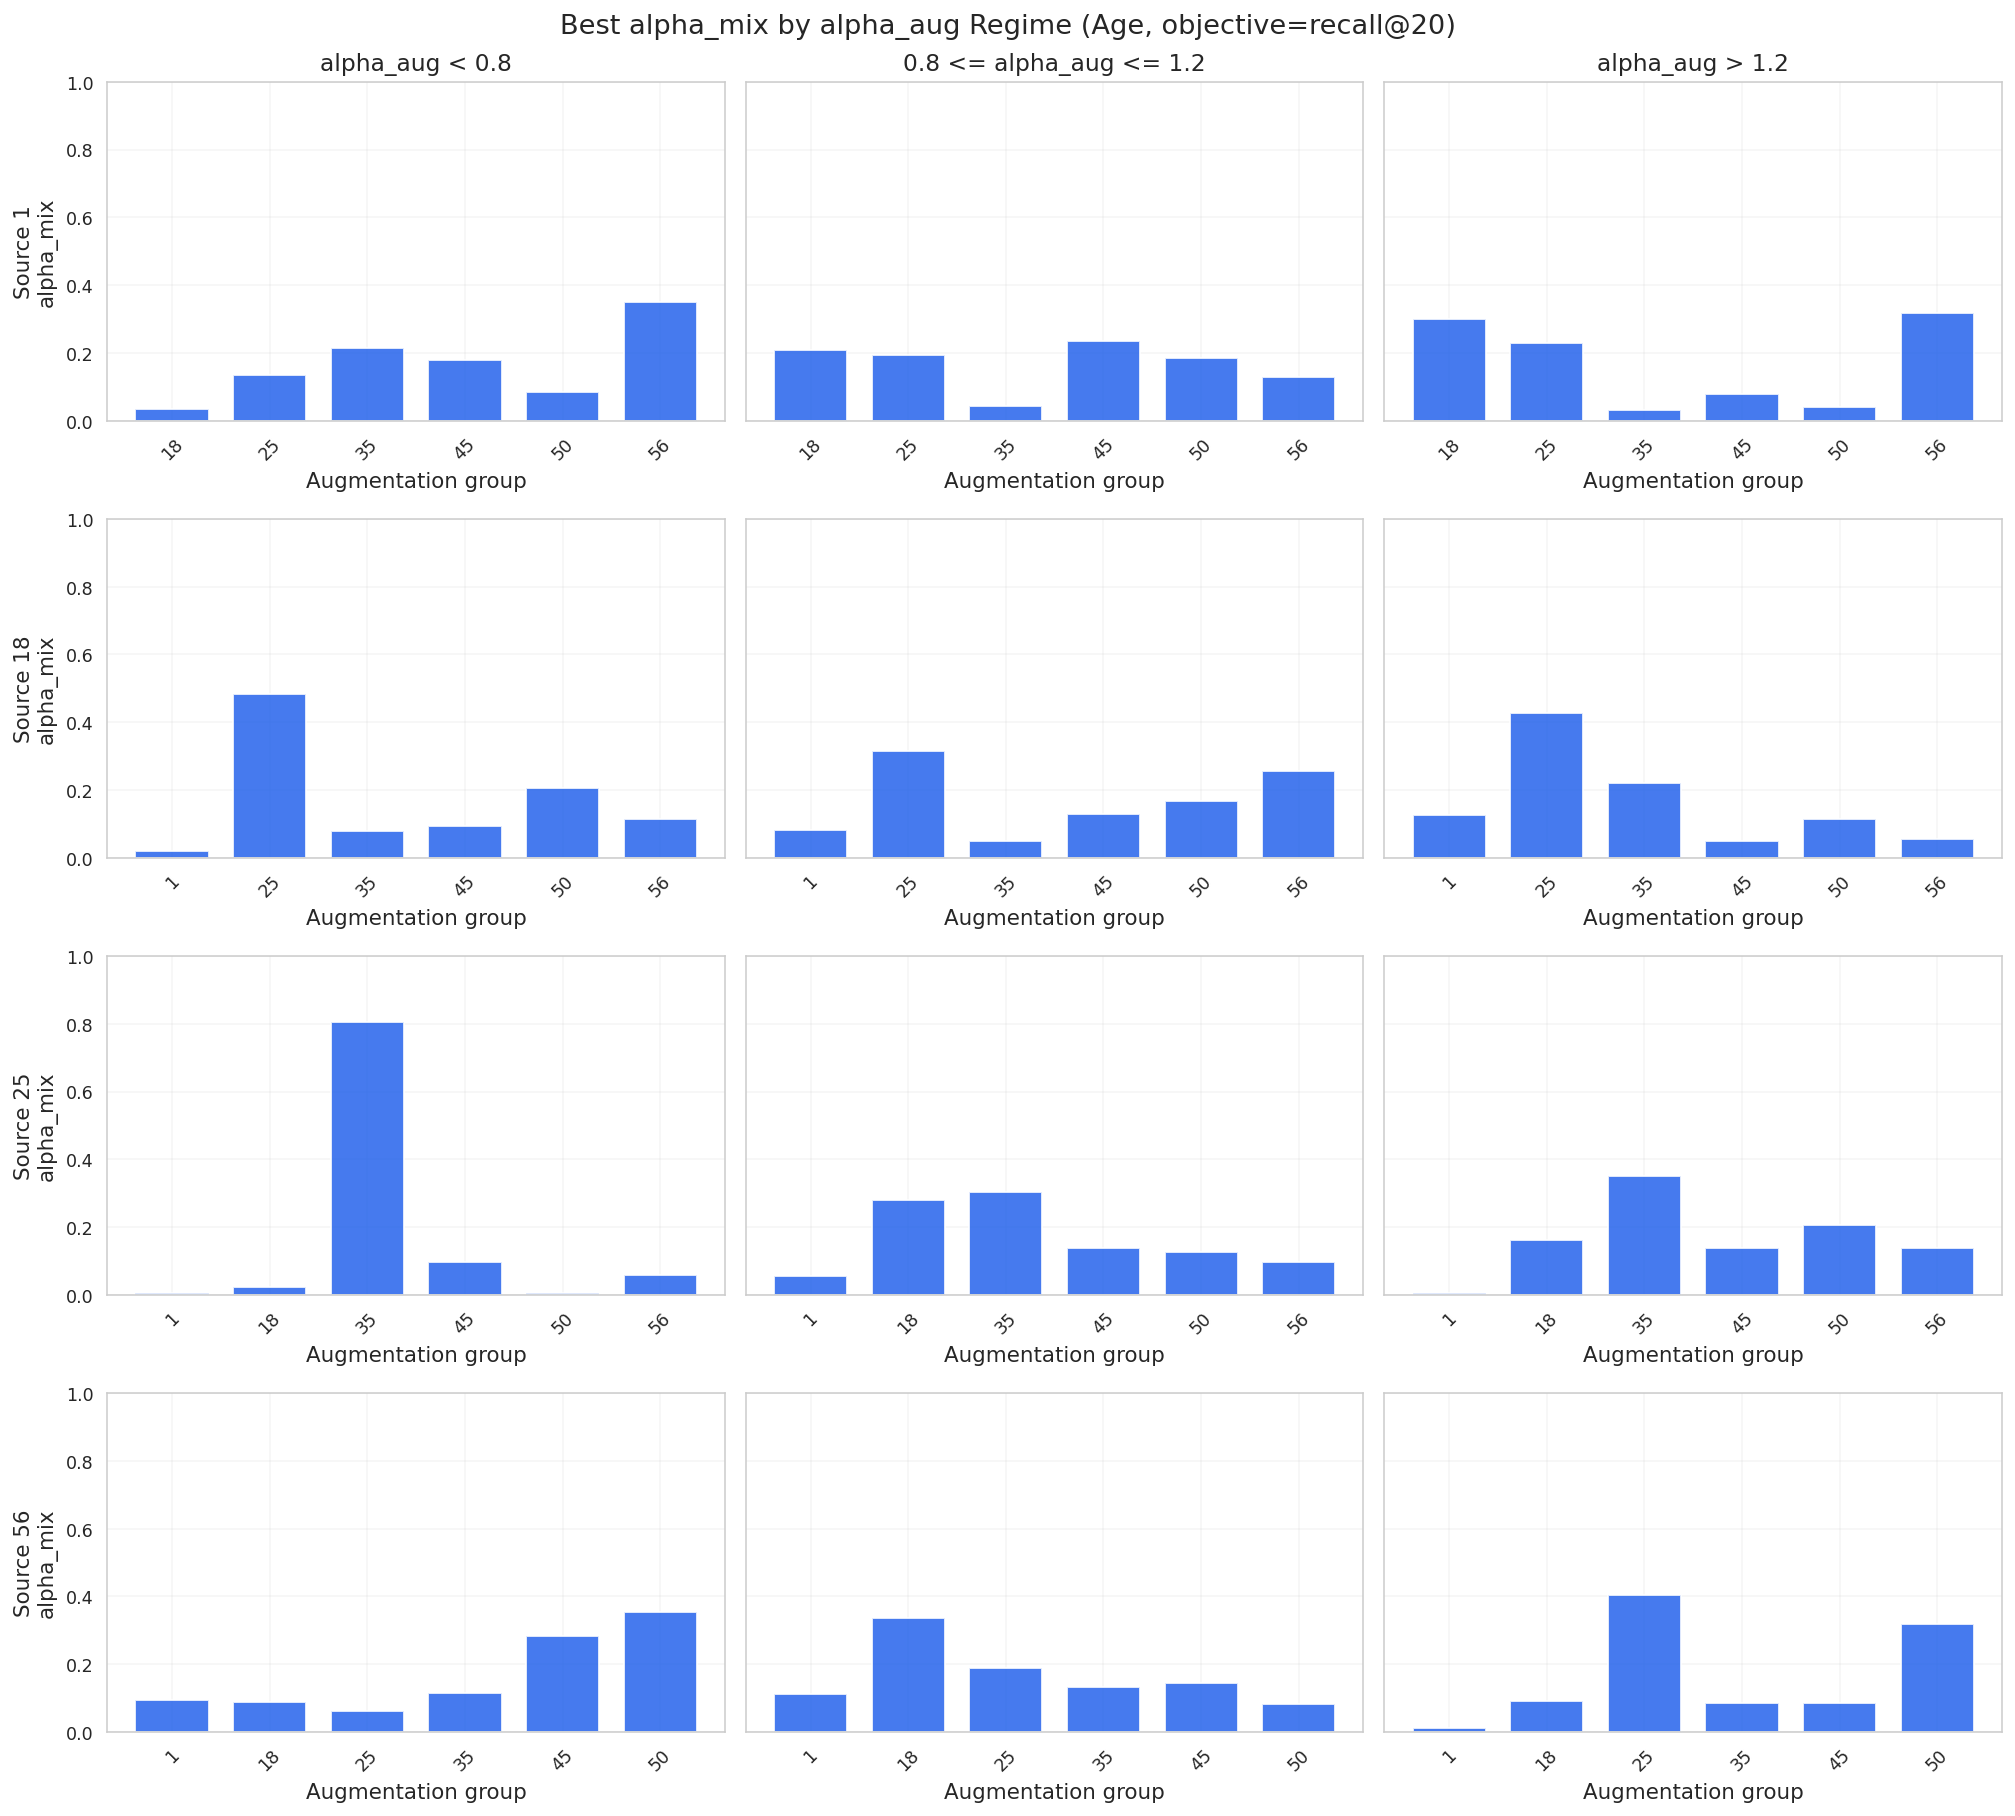

In [11]:
# Figure 4: alpha_aug bins x source groups; show best alpha_mix bar chart per cell
recall_col = METRIC_COLS["Recall"]
source_groups = sorted(df["source_label"].unique().tolist())

def alpha_aug_bin(a):
    if a < 0.8:
        return "alpha_aug < 0.8"
    if a <= 1.2:
        return "0.8 <= alpha_aug <= 1.2"
    return "alpha_aug > 1.2"

bin_order = ["alpha_aug < 0.8", "0.8 <= alpha_aug <= 1.2", "alpha_aug > 1.2"]

fig, axes = plt.subplots(len(source_groups), 3, figsize=(14.5, 3.2*len(source_groups)), sharey='row')
if len(source_groups) == 1:
    axes = np.array([axes])

for r, src in enumerate(source_groups):
    sdf = df[df["source_label"] == src].copy()
    sdf["alpha_aug_bin"] = sdf["alpha_aug"].astype(float).map(alpha_aug_bin)

    all_aug_labels = sorted({k for dct in sdf["alpha_mix_dict"] for k in dct.keys()})

    for c, b in enumerate(bin_order):
        ax = axes[r, c]
        bdf = sdf[sdf["alpha_aug_bin"] == b]
        if bdf.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_ylim(0, 1)
        else:
            best_idx = bdf[recall_col].idxmax()
            best_row = bdf.loc[best_idx]
            vals = [float(best_row["alpha_mix_dict"].get(lbl, 0.0)) for lbl in all_aug_labels]
            ax.bar(all_aug_labels, vals, color="#2563EB", alpha=0.85, width=0.75)
            ax.set_ylim(0, 1)

        if r == 0:
            ax.set_title(b)
        if c == 0:
            ax.set_ylabel(f"Source {src}\nalpha_mix")
        else:
            ax.set_ylabel("")
        ax.set_xlabel("Augmentation group")
        ax.tick_params(axis="x", rotation=45)

fig.suptitle(f"Best alpha_mix by alpha_aug Regime ({FEATURE_NAME}, objective={recall_col})", y=1.01, fontsize=14)
fig.tight_layout()
plt.show()

## Test-Set Summary

This section loads test-evaluation CSVs from `gcn-ml-mixing/test` and summarizes baselines vs selected mixes per source group.

## Schema-Drift Patch For Test CSV Loading

Some `ml1m_test_eval__...csv` files were created before `proportional_perturbation` added
`perturbation_scale` and `perturbation_trial` columns. When newer rows are appended to an
older CSV/header, row lengths can differ from header length.

This loader uses `read_schema_drift_csv(...)` to normalize mixed schemas safely:

- If rows are detected with exactly 2 extra fields, it inserts
  `perturbation_scale` and `perturbation_trial` into the header and backfills blanks for old rows.
- Otherwise it applies a generic pad/extend fallback so all rows align with columns.

This is a notebook-side temporary compatibility patch so analysis can proceed without rewriting
historical CSVs.


In [12]:
# Load test-set evaluation outputs for the selected feature
TEST_DIR = Path('test')

import csv

def read_schema_drift_csv(fp):
    """
    Robust reader for mixed-schema test CSVs where some rows/files include
    perturbation columns and others do not.
    """
    with open(fp, 'r', encoding='utf-8', newline='') as f:
        rows = list(csv.reader(f))

    if not rows:
        return pd.DataFrame()

    header = rows[0]
    data = rows[1:]
    max_len = max((len(r) for r in data), default=len(header))

    # Case: newer rows have 2 extra fields (perturbation_scale, perturbation_trial)
    # but header came from older schema.
    if (
        'perturbation_scale' not in header
        and 'perturbation_trial' not in header
        and max_len == len(header) + 2
    ):
        if 'validation_trial_type' in header:
            ins = header.index('validation_trial_type') + 1
        else:
            ins = len(header)

        header = header[:ins] + ['perturbation_scale', 'perturbation_trial'] + header[ins:]

        fixed = []
        for r in data:
            if len(r) == len(header) - 2:
                # Old-schema row: insert blanks for perturbation columns.
                r = r[:ins] + ['', ''] + r[ins:]
            fixed.append(r)
        data = fixed
    else:
        # Generic fallback: pad rows or extend header if needed.
        if max_len > len(header):
            header = header + [f'extra_col_{i}' for i in range(max_len - len(header))]
        data = [r + [''] * (len(header) - len(r)) for r in data]

    return pd.DataFrame(data, columns=header)

def load_test_feature_csvs(feature_name, test_dir):
    pattern = f"ml1m_test_eval__feature-{feature_name}__source-*.csv"
    files = sorted(test_dir.glob(pattern))
    if not files:
        raise FileNotFoundError(
            f"No test CSV files found in {test_dir} matching {pattern}."
        )

    frames = []
    for fp in files:
        df_t = read_schema_drift_csv(fp)
        if 'feature_name' in df_t.columns:
            df_t = df_t[df_t['feature_name'].astype(str) == str(feature_name)].copy()
        if df_t.empty:
            continue
        if 'source_label' not in df_t.columns:
            suffix = fp.stem.split('__source-')[-1]
            df_t['source_label'] = suffix
        df_t['source_label'] = df_t['source_label'].astype(str)
        frames.append(df_t)

    if not frames:
        raise ValueError('Test CSV files were found but none contained rows for the selected feature.')

    out = pd.concat(frames, ignore_index=True)
    test_metric_cols = {
        'Precision': sorted([c for c in out.columns if c.startswith('precision@')], key=lambda x: int(x.split('@')[1]))[0],
        'Recall': sorted([c for c in out.columns if c.startswith('recall@')], key=lambda x: int(x.split('@')[1]))[0],
        'NDCG': sorted([c for c in out.columns if c.startswith('ndcg@')], key=lambda x: int(x.split('@')[1]))[0],
    }

    # Coerce numeric columns because schema-drift CSV loading returns string-typed fields.
    numeric_cols = set(test_metric_cols.values())
    numeric_cols.update([
        'alpha_aug',
        'validation_rank',
        'validation_metric_value',
        'perturbation_scale',
        'perturbation_trial',
        'final_epoch',
        'final_loss',
        'training_time_seconds',
    ])
    for col in numeric_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')

    print(f"Loaded {len(out):,} test rows from {len(frames)} file(s).")
    print('Source groups:', sorted(out['source_label'].unique().tolist()))
    print('Test metric columns:', test_metric_cols)
    return out, test_metric_cols

test_df, TEST_METRIC_COLS = load_test_feature_csvs(FEATURE_NAME, TEST_DIR)
test_df.head()


Loaded 1,834 test rows from 4 file(s).
Source groups: ['1', '18', '25', '56']
Test metric columns: {'Precision': 'precision@20', 'Recall': 'recall@20', 'NDCG': 'ndcg@20'}


,trial_type,feature_name,source_label,alpha_aug,alpha_mix_json,validation_rank,validation_metric_name,validation_metric_value,validation_trial_type,perturbation_scale,perturbation_trial,final_epoch,final_loss,training_time_seconds,precision@20,recall@20,ndcg@20
0,no_augmentation,Age,1,0.000000,"{""18"": 0.18958404950154692, ""25"": 0.3602612581...",NaN,recall@20,NaN,no_augmentation,NaN,NaN,40,0.003,111.396511,0.214865,0.220926,0.292287
1,proportional,Age,1,1.000000,"{""18"": 0.18958404950154692, ""25"": 0.3602612581...",NaN,recall@20,NaN,proportional,NaN,NaN,40,0.099,95.685813,0.245946,0.259239,0.337195
2,stratified,Age,1,1.000000,"{""18"": 0.16666666666666666, ""25"": 0.1666666666...",NaN,recall@20,NaN,stratified,NaN,NaN,40,0.093,96.200370,0.243919,0.247223,0.329468
3,top_1,Age,1,0.559340,"{""18"": 0.035077431535783035, ""25"": 0.135898356...",1.0,recall@20,0.241298,random_149,NaN,NaN,40,0.051,96.448320,0.242568,0.247171,0.328103
4,top_2,Age,1,0.631564,"{""18"": 0.21025394454349203, ""25"": 0.3274508235...",2.0,recall@20,0.239831,random_27,NaN,NaN,40,0.064,95.479920,0.242117,0.244618,0.335622


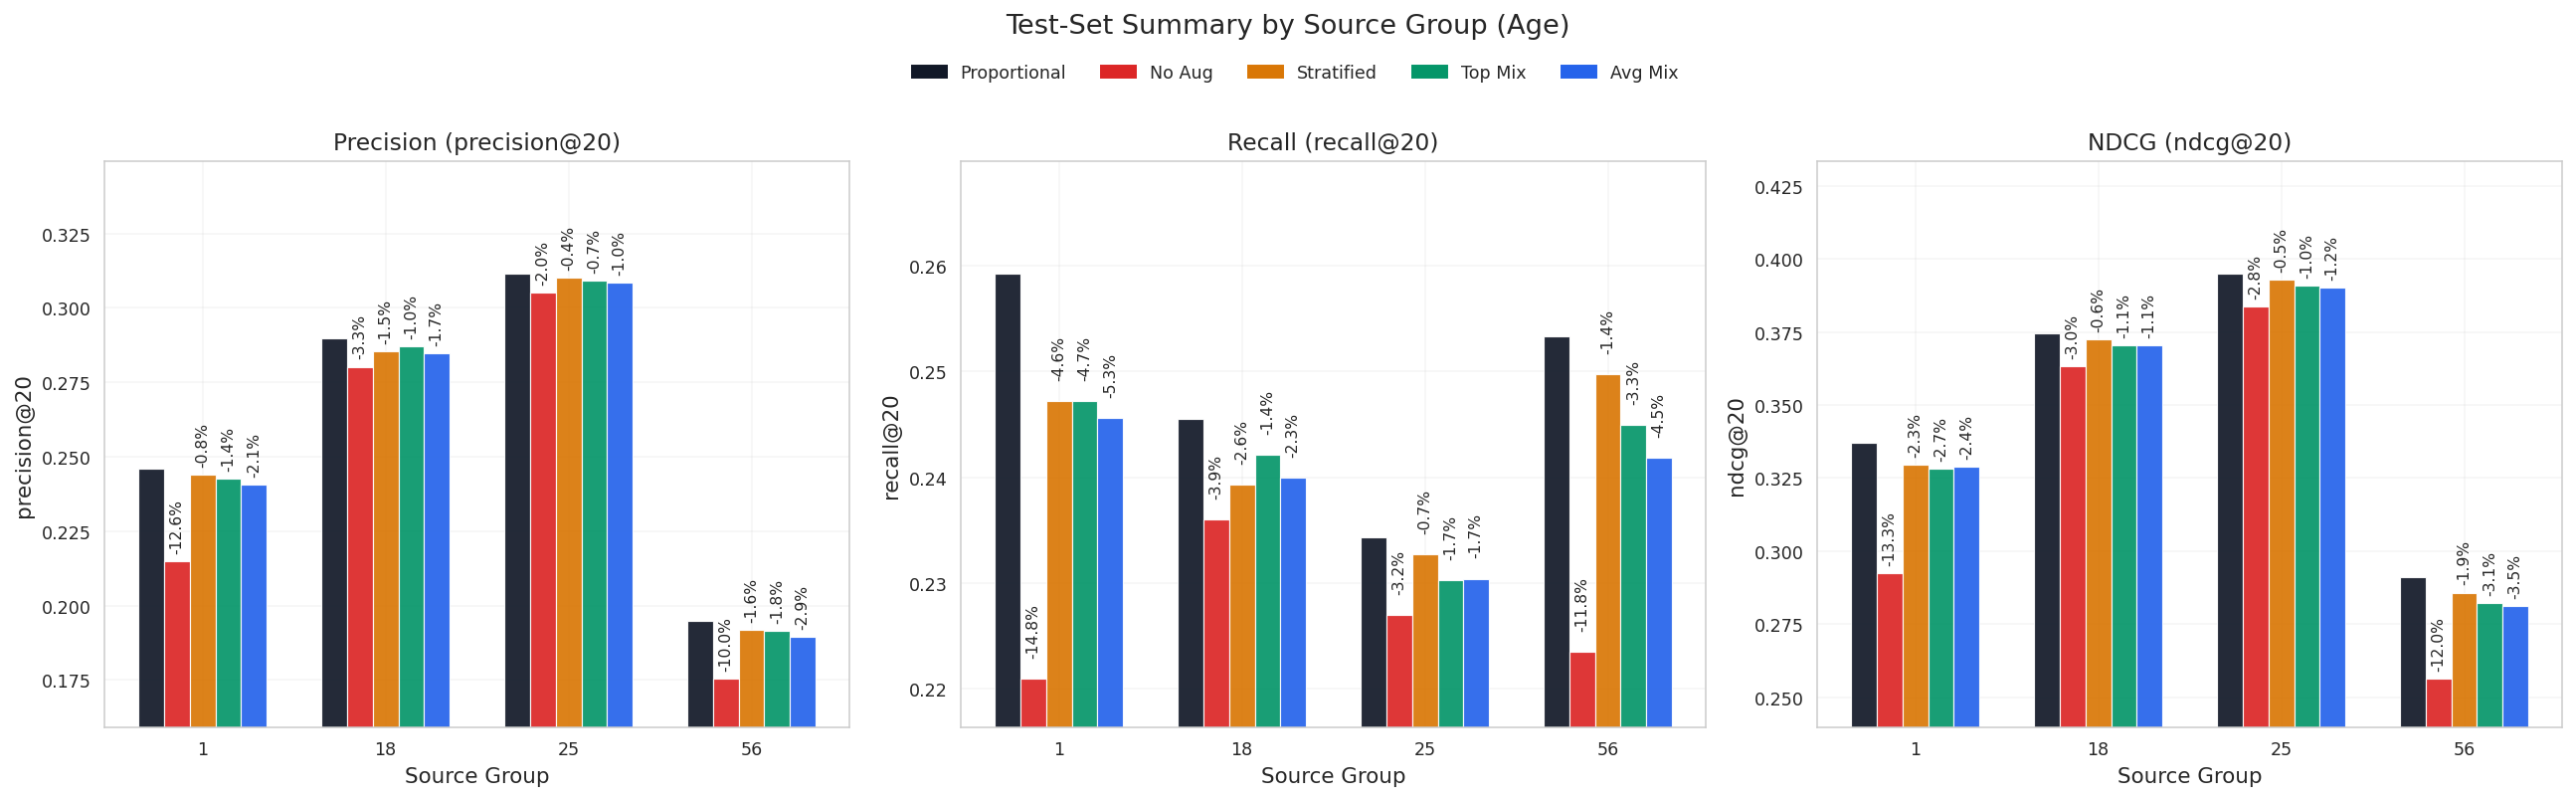

In [13]:
# Figure: grouped bars by source label, with baselines + top mix + average mix (test-set metrics)
source_groups = sorted(test_df['source_label'].unique().tolist())
metric_order = ['Precision', 'Recall', 'NDCG']

# Bar order (proportional is intentionally left-most)
bar_order = ['proportional', 'no_augmentation', 'stratified', 'top_data_mix', 'avg_data_mix']
bar_labels = {
    'proportional': 'Proportional',
    'no_augmentation': 'No Aug',
    'stratified': 'Stratified',
    'top_data_mix': 'Top Mix',
    'avg_data_mix': 'Avg Mix',
}
bar_colors = {
    'proportional': '#111827',
    'no_augmentation': '#DC2626',
    'stratified': '#D97706',
    'top_data_mix': '#059669',
    'avg_data_mix': '#2563EB',
}

def summarize_metric_by_source(df_src, metric_col):
    # Numeric-safe extraction for mixed-schema/string-loaded CSVs
    metric_series = pd.to_numeric(df_src[metric_col], errors='coerce')

    # Baselines
    prop = metric_series[df_src['trial_type'] == 'proportional']
    no_aug = metric_series[df_src['trial_type'] == 'no_augmentation']
    strat = metric_series[df_src['trial_type'] == 'stratified']

    # Top-k evaluated mixes on test are labeled top_1, top_2, ...
    top_mask = df_src['trial_type'].astype(str).str.startswith('top_')
    top_rows = df_src[top_mask].copy()
    top_metric = pd.to_numeric(top_rows[metric_col], errors='coerce') if len(top_rows) else pd.Series(dtype=float)

    top1_mask = top_rows['trial_type'].astype(str) == 'top_1' if len(top_rows) else pd.Series(dtype=bool)
    top1_vals = pd.to_numeric(top_rows.loc[top1_mask, metric_col], errors='coerce') if len(top_rows) else pd.Series(dtype=float)

    vals = {
        'proportional': float(prop.iloc[0]) if len(prop) else np.nan,
        'no_augmentation': float(no_aug.iloc[0]) if len(no_aug) else np.nan,
        'stratified': float(strat.iloc[0]) if len(strat) else np.nan,
        'top_data_mix': float(top1_vals.iloc[0]) if len(top1_vals.dropna()) else np.nan,
        'avg_data_mix': float(top_metric.mean()) if len(top_metric.dropna()) else np.nan,
    }
    return vals

fig, axes = plt.subplots(1, len(metric_order), figsize=(6.2*len(metric_order), 5.0), sharey=False)
if len(metric_order) == 1:
    axes = [axes]

x = np.arange(len(source_groups))
width = 0.14
offsets = np.linspace(-2*width, 2*width, num=len(bar_order))

for ax, metric_name in zip(axes, metric_order):
    metric_col = TEST_METRIC_COLS[metric_name]

    # Build matrix [n_source_groups x n_bar_types]
    mat = []
    for src in source_groups:
        sdf = test_df[test_df['source_label'] == src].copy()
        vals = summarize_metric_by_source(sdf, metric_col)
        mat.append([vals[b] for b in bar_order])
    mat = np.array(mat, dtype=float)
    finite_vals = mat[np.isfinite(mat)]
    if finite_vals.size > 0:
        y_min = float(np.min(finite_vals))
        y_max = float(np.max(finite_vals))
        span = max(y_max - y_min, 1e-4)
        y_pad_low = 0.12 * span
        y_pad_high = 0.28 * span
    else:
        y_min, y_max, span = 0.0, 1.0, 1.0
        y_pad_low, y_pad_high = 0.0, 0.0

    for j, b in enumerate(bar_order):
        bars = ax.bar(
            x + offsets[j],
            mat[:, j],
            width=width,
            color=bar_colors[b],
            label=bar_labels[b],
            alpha=0.92,
            edgecolor='white',
            linewidth=0.6,
        )

        # Annotate percent change vs proportional for non-proportional bars
        if b != 'proportional':
            for i_src, rect in enumerate(bars):
                y = rect.get_height()
                base = mat[i_src, bar_order.index('proportional')]
                if np.isfinite(y) and np.isfinite(base) and base != 0:
                    pct = (y - base) / base * 100.0
                    label = f"{pct:+.1f}%"
                    ax.text(
                        rect.get_x() + rect.get_width()/2,
                        y + max(0.002, 0.02 * span),
                        label,
                        ha='center', va='bottom',
                        fontsize=8, rotation=90
                    )

    ax.set_title(f"{metric_name} ({metric_col})")
    ax.set_xticks(x)
    ax.set_xticklabels(source_groups)
    ax.set_xlabel('Source Group')
    ax.set_ylabel(metric_col)
    ax.set_ylim(y_min - y_pad_low, y_max + y_pad_high)

# Figure-wide legend
handles = [plt.Rectangle((0, 0), 1, 1, color=bar_colors[b]) for b in bar_order]
labels = [bar_labels[b] for b in bar_order]
fig.legend(handles, labels, ncol=len(bar_order), loc='upper center', bbox_to_anchor=(0.5, 1.08), frameon=False)

fig.suptitle(f"Test-Set Summary by Source Group ({FEATURE_NAME})", y=1.14, fontsize=14)
fig.tight_layout()
plt.show()

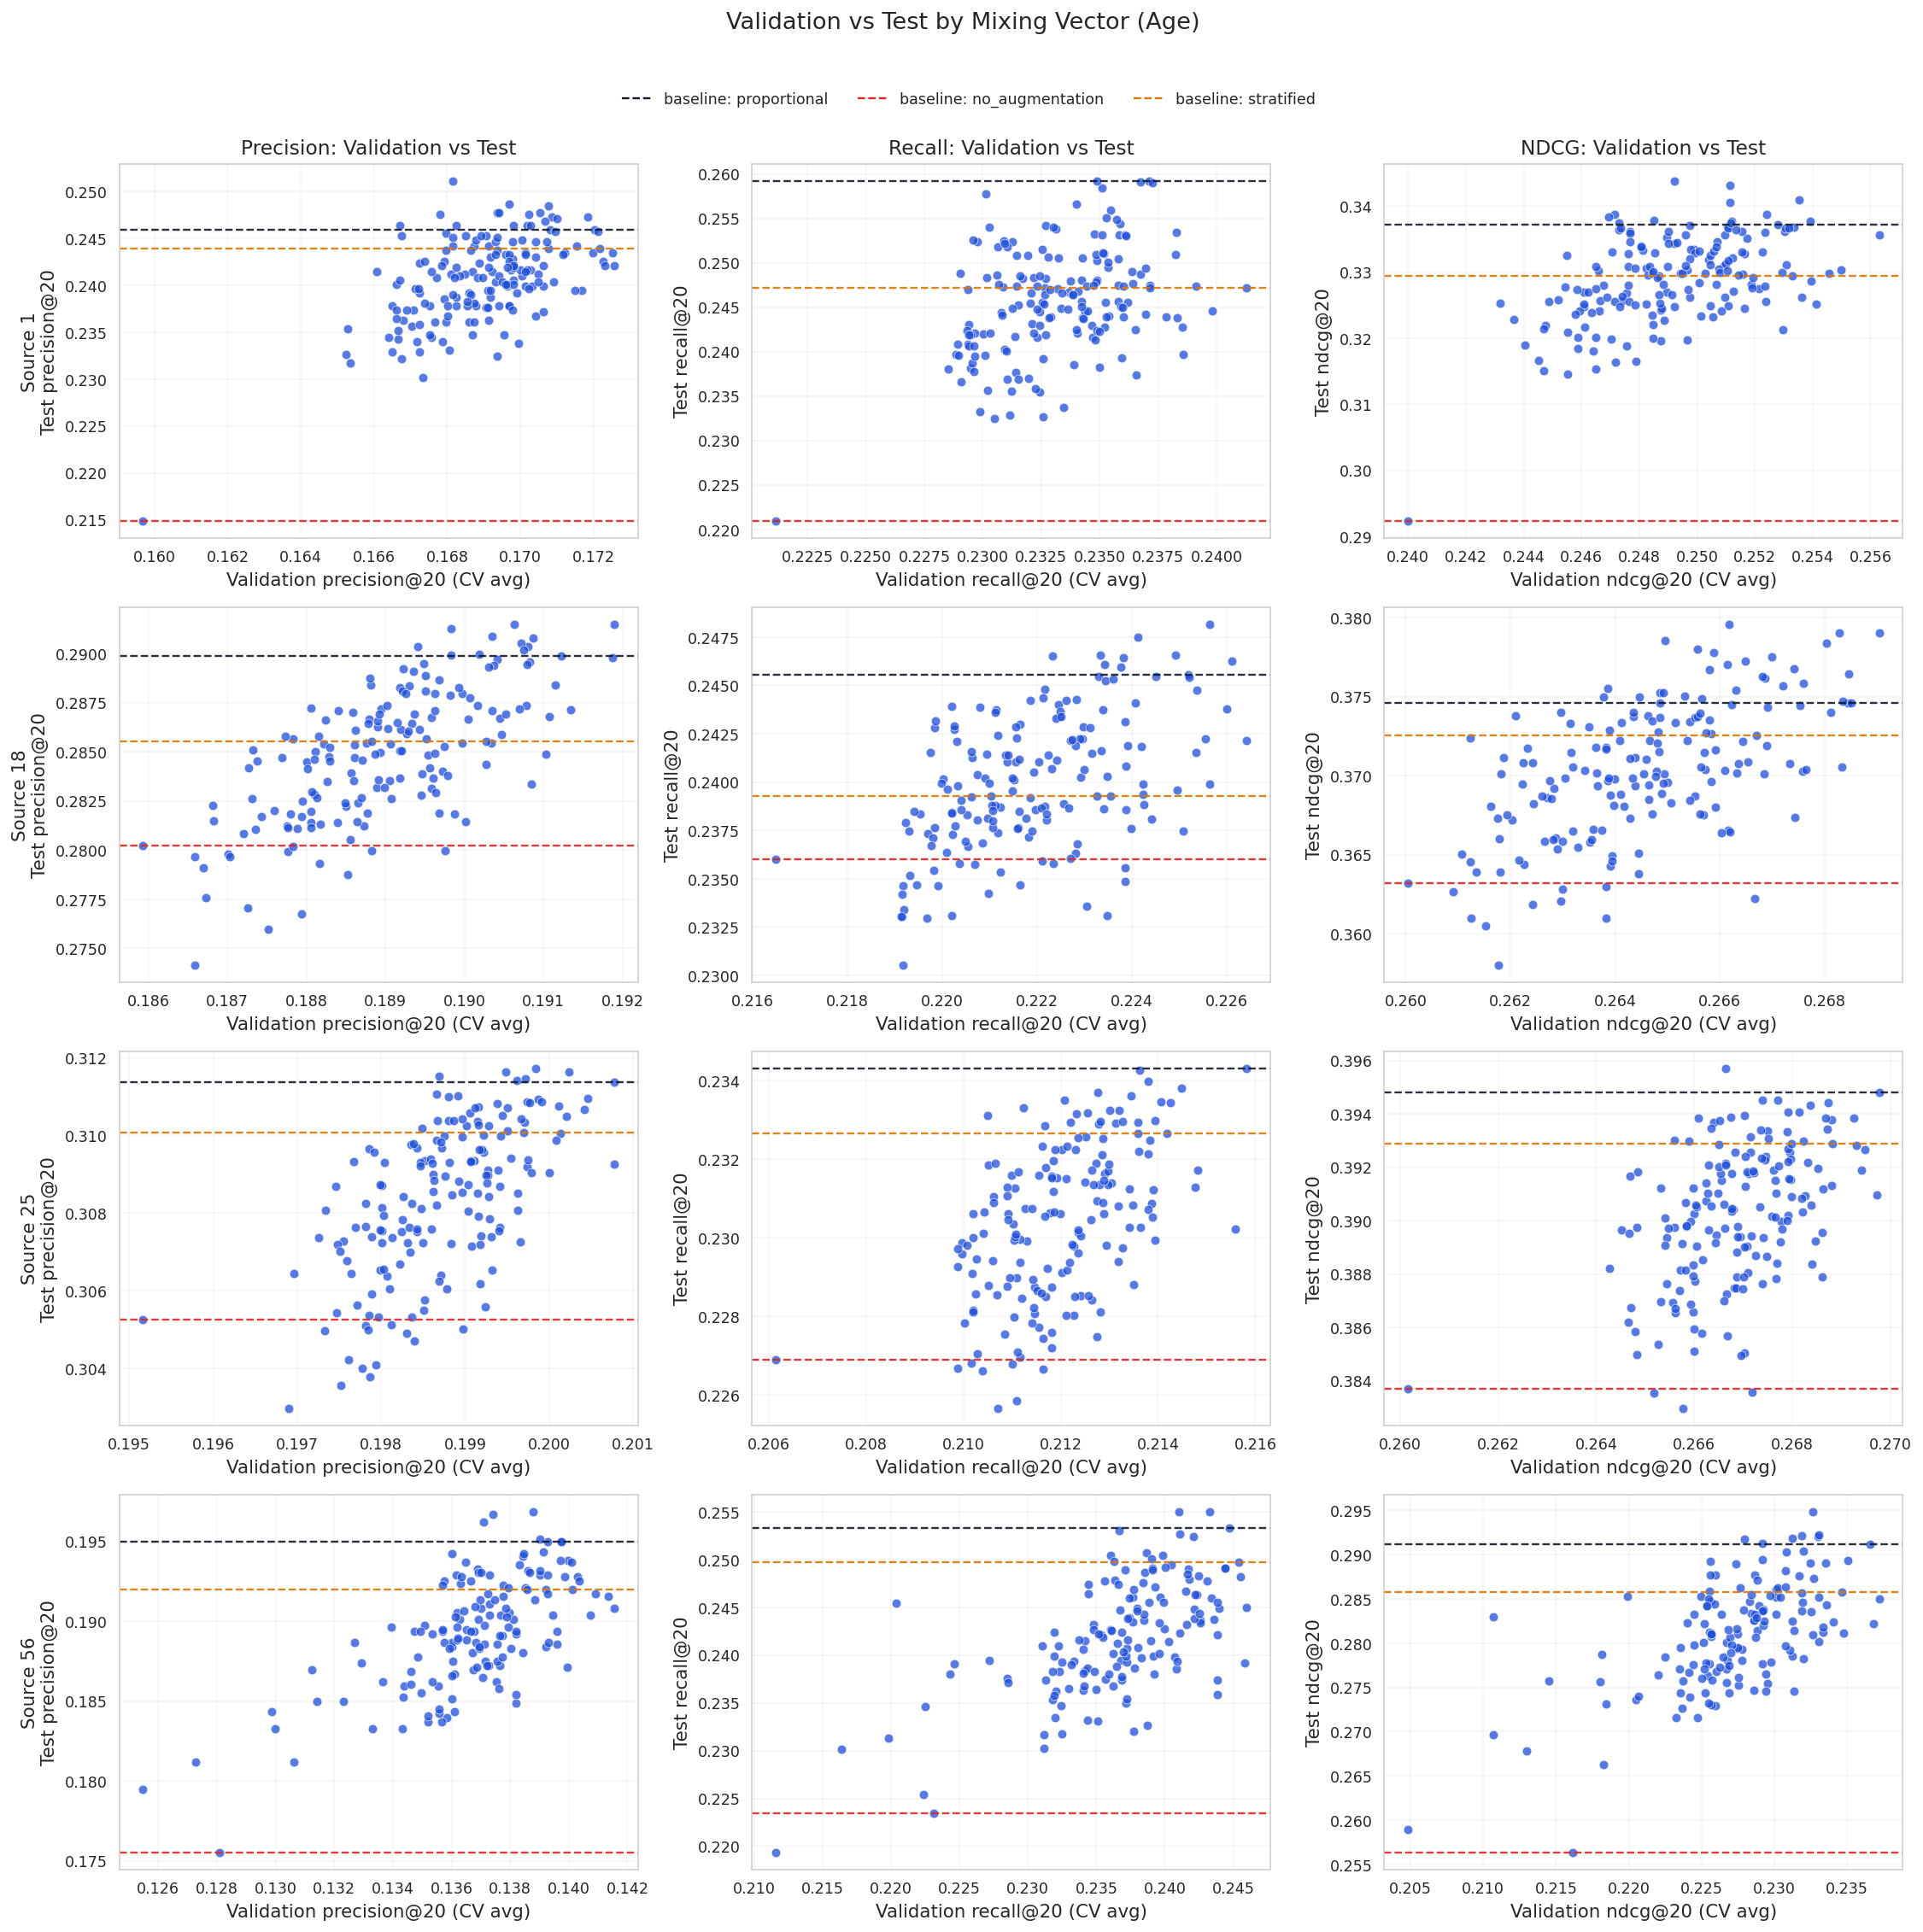

In [17]:
# Validation vs Test performance: one point per mixing ratio vector
# Layout: one row per source group, columns are metrics.
if 'df_alpha_cv' not in globals():
    raise RuntimeError('Run validation aggregation cells first (df_alpha_cv missing).')
if 'test_df' not in globals() or 'TEST_METRIC_COLS' not in globals():
    raise RuntimeError('Run test loading cell first (test_df / TEST_METRIC_COLS missing).')

val_tbl = df_alpha_cv.copy()
tst_tbl = test_df.copy()
if 'feature_name' not in val_tbl.columns:
    val_tbl['feature_name'] = str(FEATURE_NAME)
if 'feature_name' not in tst_tbl.columns:
    tst_tbl['feature_name'] = str(FEATURE_NAME)
if 'source_label' not in val_tbl.columns:
    raise KeyError('Validation table is missing source_label.')
if 'source_label' not in tst_tbl.columns:
    raise KeyError('Test table is missing source_label.')

metric_cols_test = [c for c in tst_tbl.columns if c.startswith('precision@') or c.startswith('recall@') or c.startswith('ndcg@')]
if not metric_cols_test:
    raise RuntimeError('No test metric columns found.')

merge_keys = ['feature_name', 'source_label', 'alpha_aug', 'alpha_mix_json']
test_agg = tst_tbl.groupby(merge_keys, as_index=False)[metric_cols_test].mean()

baseline_types = ['proportional', 'no_augmentation', 'stratified']
baseline_test = (
    tst_tbl[tst_tbl['trial_type'].isin(baseline_types)]
    .groupby(['source_label', 'trial_type'], as_index=False)[metric_cols_test]
    .mean()
)
baseline_colors = {
    'proportional': '#111827',
    'no_augmentation': '#DC2626',
    'stratified': '#D97706',
}

vt = val_tbl.merge(test_agg, on=merge_keys, suffixes=('_val', '_test'))
if vt.empty:
    raise RuntimeError('No overlap between validation and test mixing vectors for current feature/source.')

def resolve_col(df_, base, pref):
    if base in df_.columns:
        return base
    cand = f'{base}_{pref}'
    if cand in df_.columns:
        return cand
    prefixed = [c for c in df_.columns if c.startswith(base)]
    if prefixed:
        return prefixed[0]
    raise KeyError(f'Could not resolve metric column for {base}.')

metric_order = ['Precision', 'Recall', 'NDCG']
source_groups = sorted(vt['source_label'].astype(str).unique().tolist())
nrows, ncols = len(source_groups), len(metric_order)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.4*ncols, 3.8*nrows), sharex=False, sharey=False)
if nrows == 1:
    axes = np.array([axes])

for r, src in enumerate(source_groups):
    src_vt = vt[vt['source_label'].astype(str) == src]
    src_baselines = baseline_test[baseline_test['source_label'].astype(str) == src]

    for c, m in enumerate(metric_order):
        ax = axes[r, c]
        v_base = METRIC_COLS[m]
        t_base = TEST_METRIC_COLS[m]
        vcol = resolve_col(src_vt, v_base, 'val')
        tcol = resolve_col(src_vt, t_base, 'test')

        ax.scatter(
            src_vt[vcol],
            src_vt[tcol],
            s=30,
            alpha=0.75,
            color='#1D4ED8',
            edgecolors='white',
            linewidths=0.4,
        )

        vals = pd.concat([src_vt[vcol], src_vt[tcol]], axis=0).dropna()
#         if not vals.empty:
#             lo, hi = float(vals.min()), float(vals.max())
#             pad = max((hi - lo) * 0.05, 1e-4)
#             lo, hi = lo - pad, hi + pad
#             ax.plot([lo, hi], [lo, hi], linestyle='--', linewidth=1.2, color='black', alpha=0.7)
#             ax.set_xlim(lo, hi)
#             ax.set_ylim(lo, hi)

        # Horizontal baseline lines for this source group
        tcol_baseline = resolve_col(src_baselines, t_base, 'test')
        for b in baseline_types:
            bvals = src_baselines.loc[src_baselines['trial_type'] == b, tcol_baseline].values
            if len(bvals) > 0 and np.isfinite(bvals[0]):
                ax.axhline(float(bvals[0]), linestyle='--', linewidth=1.2, color=baseline_colors[b], alpha=0.9)

        if r == 0:
            ax.set_title(f'{m}: Validation vs Test')
        ax.set_xlabel(f'Validation {v_base} (CV avg)')
        if c == 0:
            ax.set_ylabel(f'Source {src}\nTest {t_base}')
        else:
            ax.set_ylabel(f'Test {t_base}')

# Figure-wide legend for baseline lines
baseline_handles = [
    plt.Line2D([0], [0], color=baseline_colors[b], linestyle='--', linewidth=1.2, label=f'baseline: {b}')
    for b in baseline_types
]
fig.legend(handles=baseline_handles, loc='upper center', ncol=len(baseline_handles), frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle(f'Validation vs Test by Mixing Vector ({FEATURE_NAME})', y=1.06, fontsize=14)
fig.tight_layout()
plt.show()


In [15]:
# Debugging: nearest evaluated mixes to proportional baseline per source group
# Requires df_alpha_cv from the CV-aggregation cell.
if 'df_alpha_cv' not in globals():
    raise RuntimeError('Run the CV aggregation cell first (df_alpha_cv missing).')

NEAREST_K = 10  # includes proportional baseline itself (distance 0)

def mix_vec_from_row(row):
    mix = row['alpha_mix_dict']
    labels = sorted(mix.keys())
    vec = np.array([float(row['alpha_aug'])] + [float(mix[l]) for l in labels], dtype=float)
    return labels, vec

rows_out = []
source_groups = sorted(df_alpha_cv['source_label'].astype(str).unique().tolist())

for src in source_groups:
    sdf = df_alpha_cv[df_alpha_cv['source_label'].astype(str) == src].copy()
    if sdf.empty:
        continue

    prop_rows = sdf[sdf['trial_type'] == 'proportional']
    if prop_rows.empty:
        print(f'[warn] source={src}: no proportional baseline row found, skipping.')
        continue

    # If multiple exist, take the first deterministic one.
    prop_row = prop_rows.sort_values(['alpha_aug', 'alpha_mix_json']).iloc[0]
    prop_labels, prop_vec = mix_vec_from_row(prop_row)

    for _, row in sdf.iterrows():
        mix = row['alpha_mix_dict']
        row_labels = sorted(mix.keys())
        if row_labels != prop_labels:
            # Compare on union key set for robustness
            all_labels = sorted(set(prop_labels) | set(row_labels))
            row_vec = np.array([float(row['alpha_aug'])] + [float(mix.get(l, 0.0)) for l in all_labels], dtype=float)
            prop_vec_use = np.array([float(prop_row['alpha_aug'])] + [float(prop_row['alpha_mix_dict'].get(l, 0.0)) for l in all_labels], dtype=float)
            dist = float(np.linalg.norm(row_vec - prop_vec_use))
        else:
            _, row_vec = mix_vec_from_row(row)
            dist = float(np.linalg.norm(row_vec - prop_vec))

        rounded_mix = {k: round(float(v), 2) for k, v in row['alpha_mix_dict'].items()}
        rows_out.append({
            'source_label': str(src),
            'trial_type': str(row['trial_type']),
            'alpha_aug': round(float(row['alpha_aug']), 2),
            'alpha_mix_json': json.dumps(rounded_mix, sort_keys=True),
            'distance_to_proportional': dist,
            METRIC_COLS['Recall']: float(row[METRIC_COLS['Recall']]),
            METRIC_COLS['Precision']: float(row[METRIC_COLS['Precision']]),
            METRIC_COLS['NDCG']: float(row[METRIC_COLS['NDCG']]),
        })

debug_df = pd.DataFrame(rows_out)
if debug_df.empty:
    raise RuntimeError('No rows produced for proportional-distance debug table.')

debug_df = debug_df.sort_values(['source_label', 'distance_to_proportional', 'trial_type']).reset_index(drop=True)
debug_df['nearest_rank'] = debug_df.groupby('source_label')['distance_to_proportional'].rank(method='first', ascending=True).astype(int)
nearest_df = debug_df[debug_df['nearest_rank'] <= NEAREST_K].copy()

for src in source_groups:
    sdf = nearest_df[nearest_df['source_label'] == str(src)].copy()
    if sdf.empty:
        continue
    print(f'\n=== Source {src}: nearest {NEAREST_K} mixes to proportional baseline ===')
    display_cols = [
        'nearest_rank', 'trial_type', 'distance_to_proportional',
        'alpha_aug', 'alpha_mix_json',
        METRIC_COLS['Recall'], METRIC_COLS['Precision'], METRIC_COLS['NDCG'],
    ]
    with pd.option_context('display.max_colwidth', None, 'display.width', 2000, 'display.max_columns', None):
        display(sdf[display_cols].sort_values('nearest_rank'))



=== Source 1: nearest 10 mixes to proportional baseline ===


,nearest_rank,trial_type,distance_to_proportional,alpha_aug,alpha_mix_json,recall@20,precision@20,ndcg@20
0,1,proportional,0.000000,1.00,"{""18"": 0.19, ""25"": 0.36, ""35"": 0.21, ""45"": 0.09, ""50"": 0.09, ""56"": 0.07}",0.237110,0.170811,0.252797
1,2,random_9,0.118110,0.96,"{""18"": 0.11, ""25"": 0.34, ""35"": 0.19, ""45"": 0.13, ""50"": 0.15, ""56"": 0.08}",0.238255,0.172523,0.254560
2,3,random_24,0.204817,0.99,"{""18"": 0.18, ""25"": 0.28, ""35"": 0.18, ""45"": 0.07, ""50"": 0.04, ""56"": 0.25}",0.234774,0.170946,0.251071
3,4,random_102,0.226131,0.98,"{""18"": 0.25, ""25"": 0.33, ""35"": 0.01, ""45"": 0.16, ""50"": 0.11, ""56"": 0.13}",0.231255,0.168739,0.248551
4,5,random_90,0.234048,1.18,"{""18"": 0.26, ""25"": 0.36, ""35"": 0.1, ""45"": 0.12, ""50"": 0.04, ""56"": 0.13}",0.235128,0.170270,0.247286
5,6,stratified,0.248156,1.00,"{""18"": 0.17, ""25"": 0.17, ""35"": 0.17, ""45"": 0.17, ""50"": 0.17, ""56"": 0.17}",0.237157,0.172162,0.253287
6,7,random_53,0.259641,0.89,"{""18"": 0.17, ""25"": 0.32, ""35"": 0.1, ""45"": 0.3, ""50"": 0.06, ""56"": 0.05}",0.237252,0.170991,0.253544
7,8,random_107,0.264529,1.22,"{""18"": 0.25, ""25"": 0.29, ""35"": 0.3, ""45"": 0.05, ""50"": 0.08, ""56"": 0.03}",0.235354,0.169775,0.253927
8,9,random_131,0.291598,0.95,"{""18"": 0.08, ""25"": 0.31, ""35"": 0.05, ""45"": 0.13, ""50"": 0.17, ""56"": 0.26}",0.236188,0.170045,0.251436
9,10,random_36,0.305723,1.04,"{""18"": 0.06, ""25"": 0.27, ""35"": 0.06, ""45"": 0.18, ""50"": 0.21, ""56"": 0.22}",0.232675,0.169820,0.249653



=== Source 18: nearest 10 mixes to proportional baseline ===


,nearest_rank,trial_type,distance_to_proportional,alpha_aug,alpha_mix_json,recall@20,precision@20,ndcg@20
223,1,proportional,0.000000,1.00,"{""1"": 0.04, ""25"": 0.42, ""35"": 0.24, ""45"": 0.11, ""50"": 0.1, ""56"": 0.08}",0.225199,0.191224,0.268435
224,2,random_9,0.139620,0.96,"{""1"": 0.11, ""25"": 0.34, ""35"": 0.19, ""45"": 0.13, ""50"": 0.15, ""56"": 0.08}",0.226109,0.191895,0.269042
225,3,random_56,0.257297,0.98,"{""1"": 0.04, ""25"": 0.47, ""35"": 0.1, ""45"": 0.31, ""50"": 0.03, ""56"": 0.04}",0.224081,0.190308,0.266304
226,4,random_68,0.267799,0.88,"{""1"": 0.0, ""25"": 0.63, ""35"": 0.17, ""45"": 0.08, ""50"": 0.03, ""56"": 0.1}",0.225649,0.190626,0.267593
227,5,random_132,0.272528,1.00,"{""1"": 0.02, ""25"": 0.5, ""35"": 0.04, ""45"": 0.16, ""50"": 0.06, ""56"": 0.23}",0.225212,0.191151,0.268462
228,6,random_24,0.278029,0.99,"{""1"": 0.18, ""25"": 0.28, ""35"": 0.18, ""45"": 0.07, ""50"": 0.04, ""56"": 0.25}",0.222404,0.189927,0.265331
229,7,random_131,0.299965,0.95,"{""1"": 0.08, ""25"": 0.31, ""35"": 0.05, ""45"": 0.13, ""50"": 0.17, ""56"": 0.26}",0.224928,0.190798,0.266173
230,8,random_53,0.308362,0.89,"{""1"": 0.17, ""25"": 0.32, ""35"": 0.1, ""45"": 0.3, ""50"": 0.06, ""56"": 0.05}",0.222137,0.189483,0.267196
231,9,random_36,0.308493,1.04,"{""1"": 0.06, ""25"": 0.27, ""35"": 0.06, ""45"": 0.18, ""50"": 0.21, ""56"": 0.22}",0.223332,0.190372,0.266804
232,10,random_88,0.311375,1.29,"{""1"": 0.05, ""25"": 0.51, ""35"": 0.23, ""45"": 0.07, ""50"": 0.04, ""56"": 0.1}",0.223778,0.189828,0.266140



=== Source 25: nearest 10 mixes to proportional baseline ===


,nearest_rank,trial_type,distance_to_proportional,alpha_aug,alpha_mix_json,recall@20,precision@20,ndcg@20
444,1,proportional,0.000000,1.00,"{""1"": 0.06, ""18"": 0.28, ""35"": 0.3, ""45"": 0.14, ""50"": 0.13, ""56"": 0.1}",0.215826,0.200778,0.269772
445,2,random_9,0.147312,0.96,"{""1"": 0.11, ""18"": 0.34, ""35"": 0.19, ""45"": 0.13, ""50"": 0.15, ""56"": 0.08}",0.214247,0.200420,0.269474
446,3,stratified,0.225294,1.00,"{""1"": 0.17, ""18"": 0.17, ""35"": 0.17, ""45"": 0.17, ""50"": 0.17, ""56"": 0.17}",0.213593,0.199695,0.267976
447,4,random_24,0.256159,0.99,"{""1"": 0.18, ""18"": 0.28, ""35"": 0.18, ""45"": 0.07, ""50"": 0.04, ""56"": 0.25}",0.211818,0.198760,0.266757
448,5,random_35,0.265528,0.98,"{""1"": 0.0, ""18"": 0.15, ""35"": 0.24, ""45"": 0.2, ""50"": 0.33, ""56"": 0.09}",0.212070,0.198965,0.267436
449,6,random_80,0.286698,1.12,"{""1"": 0.04, ""18"": 0.28, ""35"": 0.41, ""45"": 0.02, ""50"": 0.0, ""56"": 0.25}",0.211874,0.198631,0.266292
450,7,random_36,0.290671,1.04,"{""1"": 0.06, ""18"": 0.27, ""35"": 0.06, ""45"": 0.18, ""50"": 0.21, ""56"": 0.22}",0.213185,0.199413,0.267933
451,8,random_158,0.296304,1.07,"{""1"": 0.21, ""18"": 0.17, ""35"": 0.47, ""45"": 0.12, ""50"": 0.01, ""56"": 0.02}",0.212753,0.199065,0.267220
452,9,random_14,0.306658,0.97,"{""1"": 0.2, ""18"": 0.18, ""35"": 0.48, ""45"": 0.01, ""50"": 0.01, ""56"": 0.11}",0.211670,0.199103,0.266448
453,10,random_131,0.309475,0.95,"{""1"": 0.08, ""18"": 0.31, ""35"": 0.05, ""45"": 0.13, ""50"": 0.17, ""56"": 0.26}",0.211056,0.198669,0.266395



=== Source 56: nearest 10 mixes to proportional baseline ===


,nearest_rank,trial_type,distance_to_proportional,alpha_aug,alpha_mix_json,recall@20,precision@20,ndcg@20
666,1,proportional,0.000000,1.00,"{""1"": 0.04, ""18"": 0.19, ""25"": 0.37, ""35"": 0.21, ""45"": 0.1, ""50"": 0.09}",0.244740,0.139737,0.236571
667,2,random_9,0.261545,0.96,"{""1"": 0.11, ""18"": 0.34, ""25"": 0.19, ""35"": 0.13, ""45"": 0.15, ""50"": 0.08}",0.242520,0.139316,0.233055
668,3,stratified,0.267457,1.00,"{""1"": 0.17, ""18"": 0.17, ""25"": 0.17, ""35"": 0.17, ""45"": 0.17, ""50"": 0.17}",0.245431,0.140132,0.234666
669,4,random_35,0.276751,0.98,"{""1"": 0.0, ""18"": 0.15, ""25"": 0.24, ""35"": 0.2, ""45"": 0.33, ""50"": 0.09}",0.237984,0.137842,0.227502
670,5,random_14,0.298085,0.97,"{""1"": 0.2, ""18"": 0.18, ""25"": 0.48, ""35"": 0.01, ""45"": 0.01, ""50"": 0.11}",0.236229,0.136105,0.227448
671,6,random_5,0.302567,0.71,"{""1"": 0.02, ""18"": 0.14, ""25"": 0.42, ""35"": 0.19, ""45"": 0.12, ""50"": 0.11}",0.244384,0.139026,0.232624
672,7,random_64,0.306359,0.88,"{""1"": 0.02, ""18"": 0.21, ""25"": 0.54, ""35"": 0.01, ""45"": 0.06, ""50"": 0.18}",0.240025,0.138447,0.231991
673,8,random_71,0.313208,1.17,"{""1"": 0.26, ""18"": 0.1, ""25"": 0.39, ""35"": 0.13, ""45"": 0.07, ""50"": 0.06}",0.236298,0.136342,0.228642
674,9,random_80,0.315022,1.12,"{""1"": 0.04, ""18"": 0.28, ""25"": 0.41, ""35"": 0.02, ""45"": 0.0, ""50"": 0.25}",0.242158,0.138658,0.233532
675,10,random_24,0.335817,0.99,"{""1"": 0.18, ""18"": 0.28, ""25"": 0.18, ""35"": 0.07, ""45"": 0.04, ""50"": 0.25}",0.241594,0.138842,0.230406


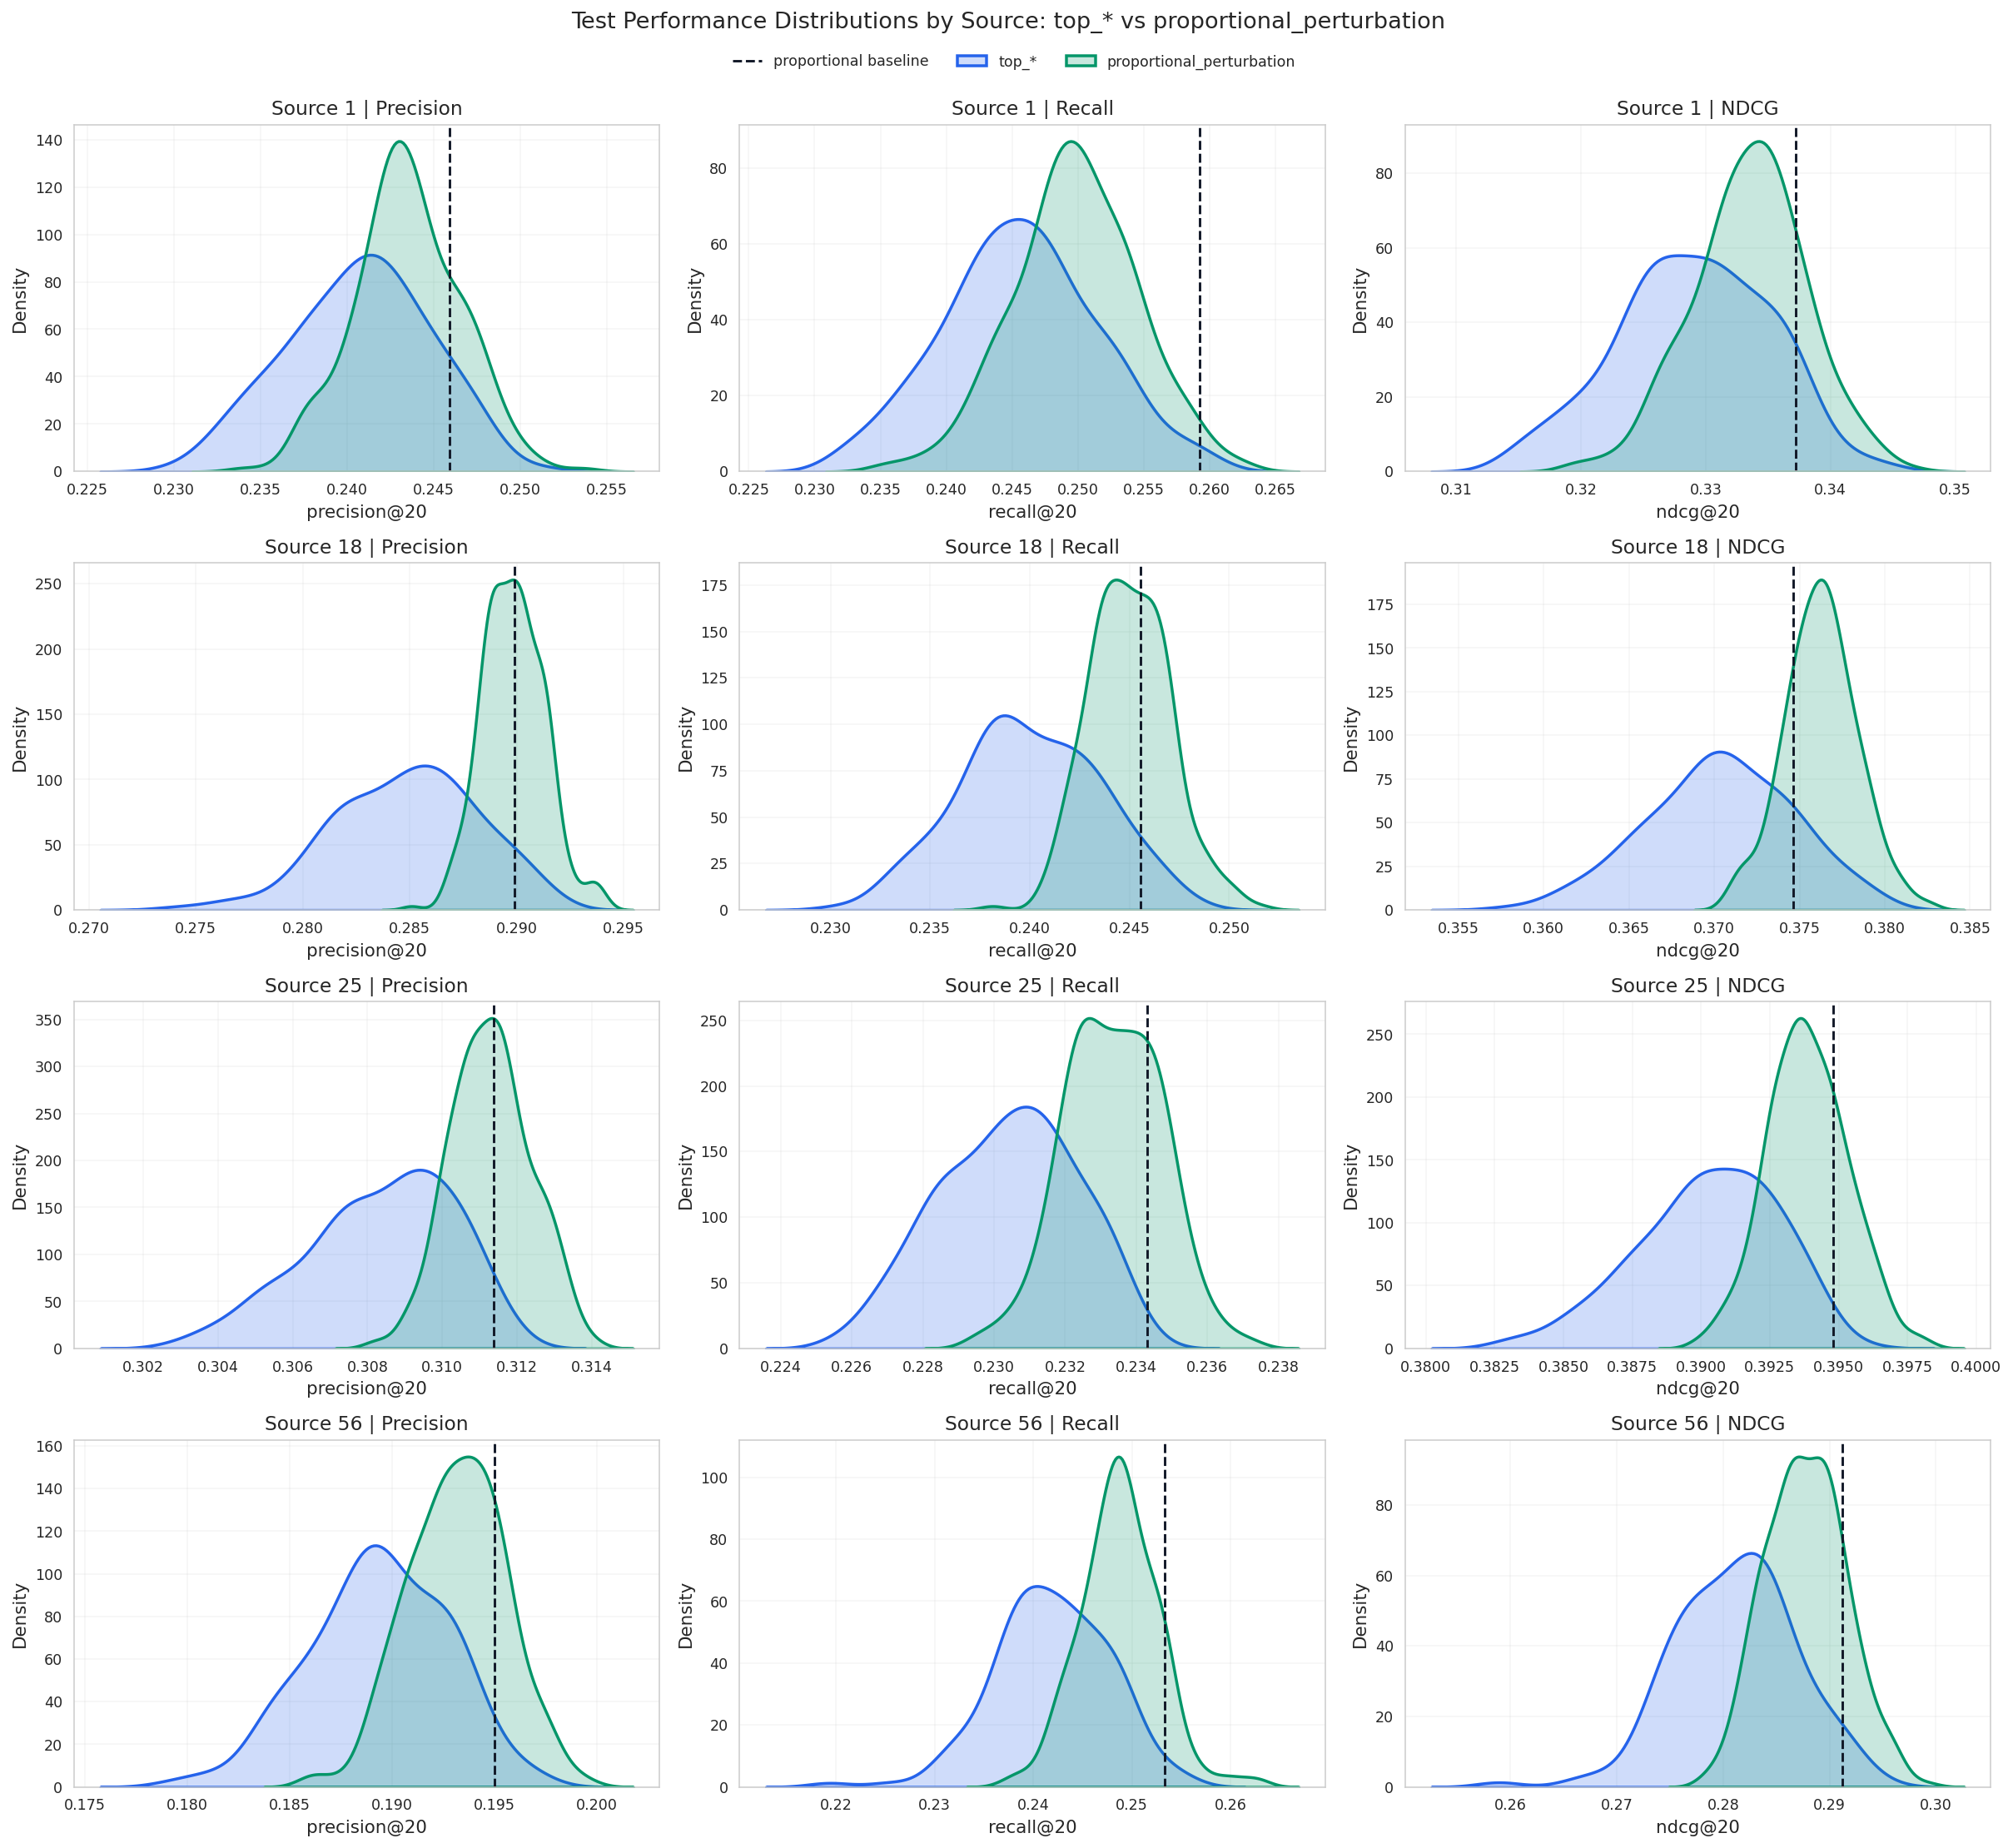

In [16]:
# Distribution comparison on test set: top_* vs proportional_perturbation (disaggregated by source)
if 'test_df' not in globals() or 'TEST_METRIC_COLS' not in globals():
    raise RuntimeError('Run the test loading cell first (test_df / TEST_METRIC_COLS missing).')

cmp_df = test_df.copy()
cmp_df['trial_type'] = cmp_df['trial_type'].astype(str)

# Ensure metric columns are numeric for robust KDE/summary behavior
for mcol in TEST_METRIC_COLS.values():
    if mcol in cmp_df.columns:
        cmp_df[mcol] = pd.to_numeric(cmp_df[mcol], errors='coerce')

cmp_df['trial_family'] = np.where(
    cmp_df['trial_type'].str.startswith('top_'),
    'top_*',
    np.where(cmp_df['trial_type'] == 'proportional_perturbation', 'proportional_perturbation', 'other')
)

source_groups = sorted(cmp_df['source_label'].astype(str).unique().tolist())
metric_order = ['Precision', 'Recall', 'NDCG']

colors = {
    'top_*': '#2563EB',
    'proportional_perturbation': '#059669',
    'proportional_baseline': '#111827',
}

nrows, ncols = len(source_groups), len(metric_order)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.8*ncols, 3.8*nrows), sharex=False, sharey=False)
if nrows == 1:
    axes = np.array([axes])

for r, src in enumerate(source_groups):
    sdf = cmp_df[cmp_df['source_label'].astype(str) == str(src)].copy()

    for c, metric_name in enumerate(metric_order):
        ax = axes[r, c]
        mcol = TEST_METRIC_COLS[metric_name]

        # Trial-family densities for this source and metric
        for fam in ['top_*', 'proportional_perturbation']:
            vals = sdf.loc[sdf['trial_family'] == fam, mcol].dropna().values
            if len(vals) >= 2 and np.std(vals) > 0:
                sns.kdeplot(
                    vals,
                    ax=ax,
                    fill=True,
                    alpha=0.22,
                    linewidth=1.8,
                    color=colors[fam],
                    label=fam,
                )
            elif len(vals) > 0:
                ax.axvline(float(vals[0]), color=colors[fam], linewidth=2.0, label=f'{fam} (single value)')

        # Proportional baseline vertical line for this source + metric
        pvals = sdf.loc[sdf['trial_type'] == 'proportional', mcol].dropna().values
        if len(pvals) > 0:
            pval = float(np.mean(pvals))
            ax.axvline(
                pval,
                color=colors['proportional_baseline'],
                linestyle='--',
                linewidth=1.5,
                label='proportional baseline',
            )

        ax.set_title(f'Source {src} | {metric_name}')
        ax.set_xlabel(mcol)
        ax.set_ylabel('Density')

# Figure-wide legend (deduplicated)
handles, labels = [], []
for ax in np.array(axes).reshape(-1):
    h, l = ax.get_legend_handles_labels()
    for hi, li in zip(h, l):
        if li not in labels:
            labels.append(li)
            handles.append(hi)
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.02), frameon=False)

fig.suptitle('Test Performance Distributions by Source: top_* vs proportional_perturbation', y=1.04, fontsize=14)
fig.tight_layout()
plt.show()
